# Intraday Momentum Breakout Strategy: End-to-End Backtest

**ES & NQ E-mini Futures Momentum Trading System**

This notebook demonstrates the complete workflow for the Intraday Momentum Breakout Strategy:
1. Data Acquisition (ES & NQ Futures)
2. Noise Area Calculation (90-day volatility boundaries)
3. Signal Generation (Breakout detection)
4. Position Sizing (Volatility targeting: 3% daily)
5. Backtesting (With realistic transaction costs)
6. Performance Evaluation

---

## Key Strategy Parameters

- **Noise Area Lookback**: 90 days (optimized from research)
- **Target Volatility**: 3% daily portfolio volatility
- **Max Leverage**: 8x
- **Portfolio Allocation**: 50% NQ momentum, 25% ES momentum, 25% NQ long-only
- **Transaction Costs**: 1 tick slippage per side + $4.20 commission
- **Trading Hours**: 9:30 AM - 4:00 PM ET (intraday only)

---

## 1. Setup & Imports

Import all required modules and configure settings.

In [1]:
import sys
import os
import warnings
import importlib

warnings.filterwarnings('ignore')

# Standard library
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime

# Reload local modules to pick up any changes
import noise_area as _na_mod
import position_sizer as _ps_mod
import signal_generator as _sg_mod
import backtester as _bt_mod
importlib.reload(_na_mod)
importlib.reload(_ps_mod)
importlib.reload(_sg_mod)
importlib.reload(_bt_mod)

# Force reimport
import sys
if 'signal_generator' in sys.modules:
    del sys.modules['signal_generator']

# Local strategy modules
from noise_area import NoiseAreaCalculator, visualize_noise_area
from signal_generator import SignalGenerator
from position_sizer import PositionSizer
from backtester import Backtester
from performance_evaluator import PerformanceEvaluator, visualize_performance

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All modules imported successfully")
print(f"Working directory: {os.getcwd()}")


All modules imported successfully
Working directory: /home/misango/codechest/Algorithmic_Trading_and_HFT_Research/Algorithmic_Strategies/Intraday_Momentum_Breakout


## 2. Load Configuration

Load strategy parameters from config file.

In [2]:
# Load configuration
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("Entry/Exit Rules:", config['strategy']['entry_exit'])

# Display key parameters
print("="*60)
print("STRATEGY CONFIGURATION")
print("="*60)
print(f"\nNoise Area:")
print(f"  Lookback: {config['strategy']['noise_area']['lookback_days']} days")
print(f"  Method: {config['strategy']['noise_area']['method']}")
print(f"  Upper percentile: {config['strategy']['noise_area']['upper_percentile']}%")
print(f"  Lower percentile: {config['strategy']['noise_area']['lower_percentile']}%")

print(f"\nPosition Sizing:")
print(f"  Target volatility: {config['strategy']['position_sizing']['target_daily_volatility']}%")
print(f"  Max leverage: {config['strategy']['position_sizing']['max_leverage']}x")
print(f"  Volatility estimation: {config['strategy']['position_sizing']['volatility_estimation']}")

print(f"\nPortfolio Allocation:")
for strategy, allocation in config['strategy']['portfolio']['allocation'].items():
    print(f"  {strategy}: {allocation}%")

print(f"\nTransaction Costs:")
print(f"  Commission: ${config['strategy']['transaction_costs']['commission_per_contract']:.2f} per contract")
print(f"  Slippage: {config['strategy']['transaction_costs']['slippage_ticks']} ticks per side")
print(f"  ES tick value: ${config['strategy']['transaction_costs']['ES']['tick_value']:.2f}")
print(f"  NQ tick value: ${config['strategy']['transaction_costs']['NQ']['tick_value']:.2f}")

print(f"\nBacktest Period:")
print(f"  Start: {config['data']['start_date']}")
print(f"  End: {config['data']['end_date']}")
print(f"  Initial Capital: ${config['strategy']['portfolio']['initial_capital']:,}")
print("="*60)

Entry/Exit Rules: {'confirmation_bars': 2, 'volume_threshold_percentile': 60, 'max_hold_bars': 78, 'min_signal_strength': 40, 'short_enabled': False, 'trend_filter_enabled': False, 'trend_period': 50}
STRATEGY CONFIGURATION

Noise Area:
  Lookback: 20 days
  Method: percentile
  Upper percentile: 80%
  Lower percentile: 20%

Position Sizing:
  Target volatility: 10.0%
  Max leverage: 8.0x
  Volatility estimation: ewma

Portfolio Allocation:
  NQ_momentum: 0.95%
  ES_momentum: 0.05%
  NQ_long_only: 0.0%

Transaction Costs:
  Commission: $2.00 per contract
  Slippage: 0.5 ticks per side
  ES tick value: $12.50
  NQ tick value: $5.00

Backtest Period:
  Start: 2011-02-01
  End: None
  Initial Capital: $2,500,000


## 3. Data Acquisition

Load ES & NQ futures data from real Databento CSV files (RTH, 5-minute bars).

In [3]:

os.makedirs('results', exist_ok=True)

es_data = pd.read_csv(
    "/home/misango/codechest/Algorithmic_Trading_and_HFT_Research/Algorithmic_Strategies/Intraday_Momentum_Breakout/Data/ES_5min_RTH.csv"
)
es_data['ts_event'] = pd.to_datetime(es_data['ts_event'], utc=True)
es_data = es_data.set_index('ts_event')

nq_data = pd.read_csv(
    "/home/misango/codechest/Algorithmic_Trading_and_HFT_Research/Algorithmic_Strategies/Intraday_Momentum_Breakout/Data/NQ_5min_RTH.csv"
)
nq_data['ts_event'] = pd.to_datetime(nq_data['ts_event'], utc=True)
nq_data = nq_data.set_index('ts_event')

print(f"Data loaded: {len(es_data)} ES bars, {len(nq_data)} NQ bars")
print(f"Date range: {es_data.index.min()} to {es_data.index.max()}")
print(f"Index type: {type(es_data.index).__name__}")


Data loaded: 306523 ES bars, 306521 NQ bars
Date range: 2011-01-03 14:25:00+00:00 to 2026-02-25 21:00:00+00:00
Index type: DatetimeIndex


### Visualize Raw Data

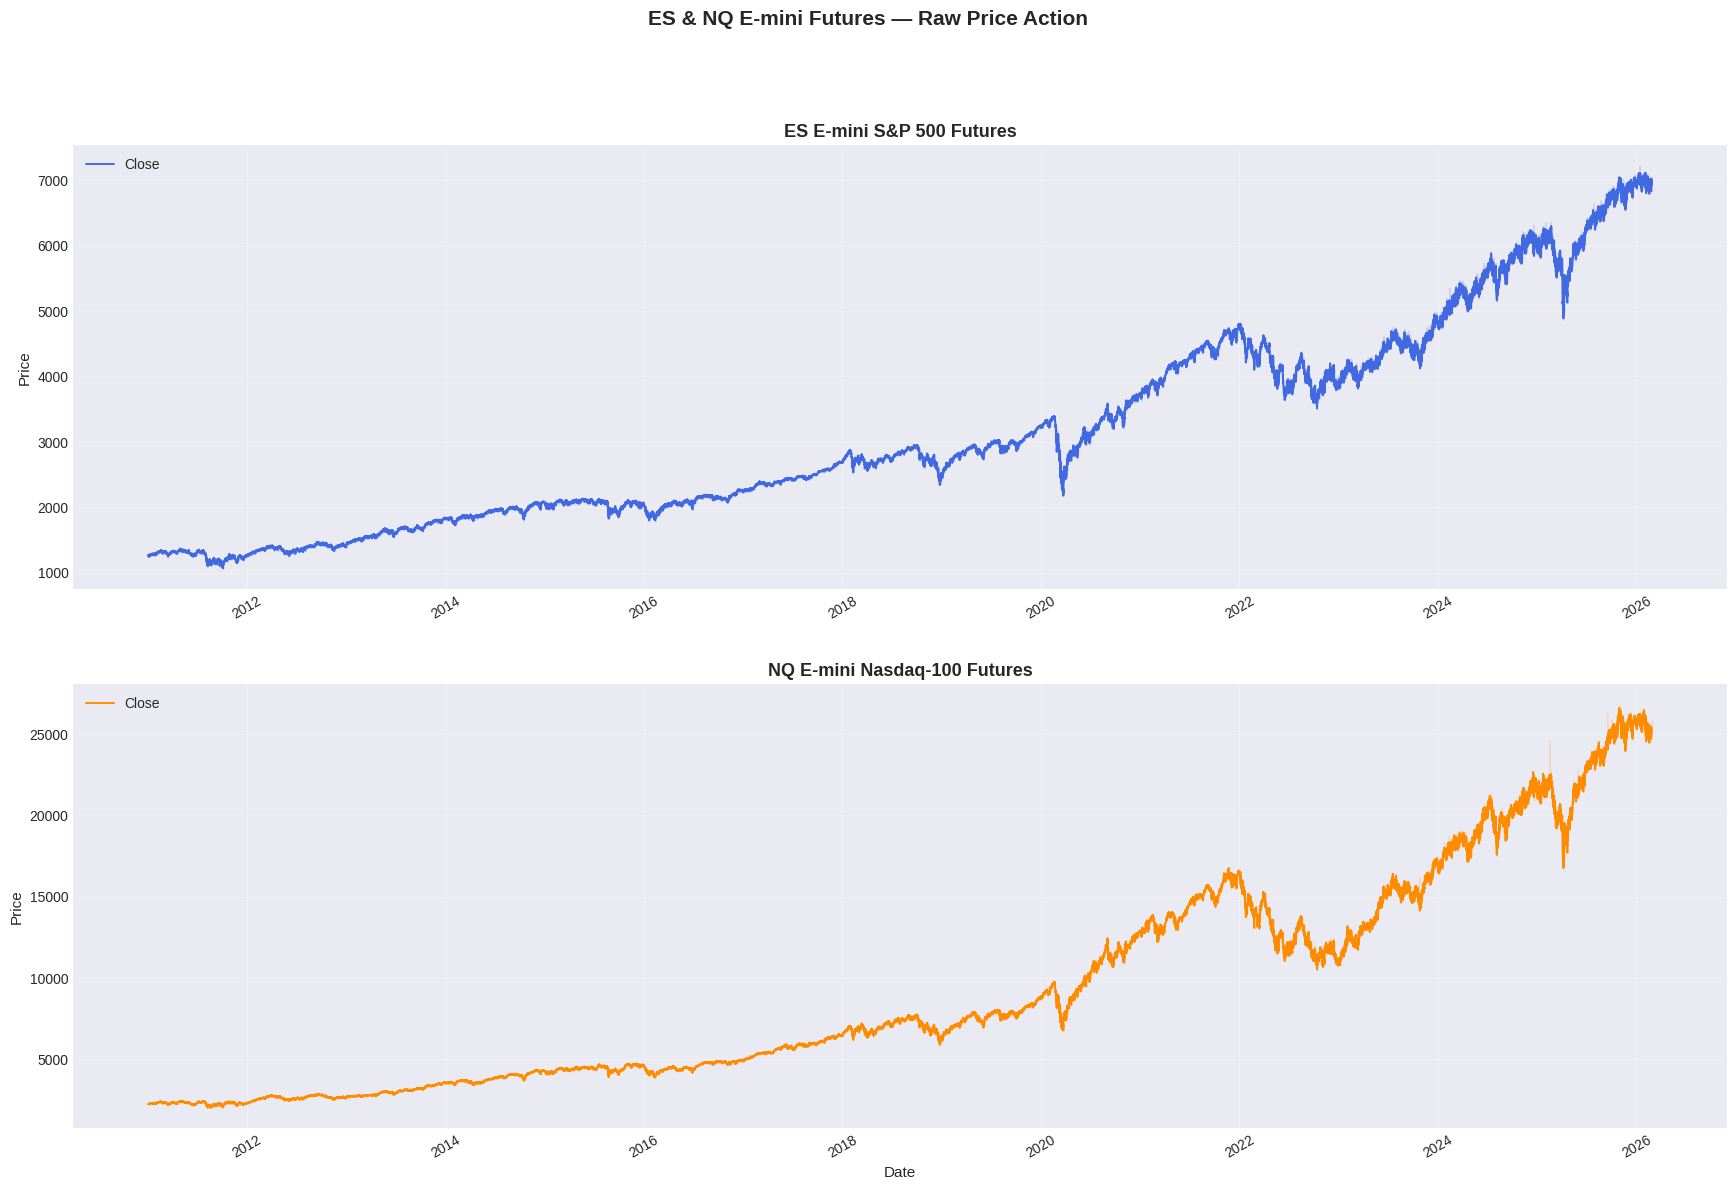

Raw data visualization saved


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.suptitle('ES & NQ E-mini Futures — Raw Price Action', fontsize=15, fontweight='bold', y=1.01)

ax = axes[0]
ax.plot(es_data.index, es_data['Close'], linewidth=1.4, label='Close', color='royalblue')
ax.fill_between(es_data.index, es_data['Low'], es_data['High'], alpha=0.18, color='royalblue')
ax.set_title('ES E-mini S&P 500 Futures', fontsize=13, fontweight='bold')
ax.set_ylabel('Price', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
ax.plot(nq_data.index, nq_data['Close'], linewidth=1.4, label='Close', color='darkorange')
ax.fill_between(nq_data.index, nq_data['Low'], nq_data['High'], alpha=0.18, color='darkorange')
ax.set_title('NQ E-mini Nasdaq-100 Futures', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout(pad=3.0)
plt.savefig('results/01_raw_price_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("Raw data visualization saved")


## 4. Noise Area Calculation

Calculate volatility-based boundaries that define "normal" price fluctuation.

In [5]:
# Use the already-loaded dataframes — no need to re-read from disk
es_data_raw = es_data.copy()
nq_data_raw = nq_data.copy()

calculator = NoiseAreaCalculator(config)

print("Calculating noise area for ES...")
es_data = calculator.calculate_noise_area(es_data_raw.copy())
es_data = calculator.identify_breakouts(es_data)

print("Calculating noise area for NQ...")
nq_data = calculator.calculate_noise_area(nq_data_raw.copy())
nq_data = calculator.identify_breakouts(nq_data)

print(f"\nNoise area calculation complete")
print(f"  ES NaN boundaries: {es_data['upper_boundary'].isna().sum()}")
print(f"  NQ NaN boundaries: {nq_data['upper_boundary'].isna().sum()}")


Calculating noise area for ES...
NOISE AREA CALCULATION
Added 'date' column. Data columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Returns', 'Log_Returns', 'Range', 'Range_Pct', 'Intraday_Return', 'date']
Calculating noise area using percentile method (20 days)...
  Filtered 5.7% outlier days (range > 136.75)
  Calculated noise area for 306523 bars (session-open anchored)
  Avg upper range: 47.48
  Avg lower range: 36.26

Validation:
  Valid boundaries: 100.0%
  Avg boundary width: 83.74
Calculating noise area for NQ...
NOISE AREA CALCULATION
Added 'date' column. Data columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Returns', 'Log_Returns', 'Range', 'Range_Pct', 'Intraday_Return', 'date']
Calculating noise area using percentile method (20 days)...
  Filtered 1.8% outlier days (range > 558.50)
  Calculated noise area for 306521 bars (session-open anchored)
  Avg upper range: 140.90
  Avg lower range: 104.27

Validation:
  Valid boundaries: 100.0%
  Avg boundary width: 245.17

No

### Visualize Noise Area & Breakouts

  [ES] Resampled to 3,892 daily bars for overview chart

Noise area visualization saved to results/ES_noise_area.png


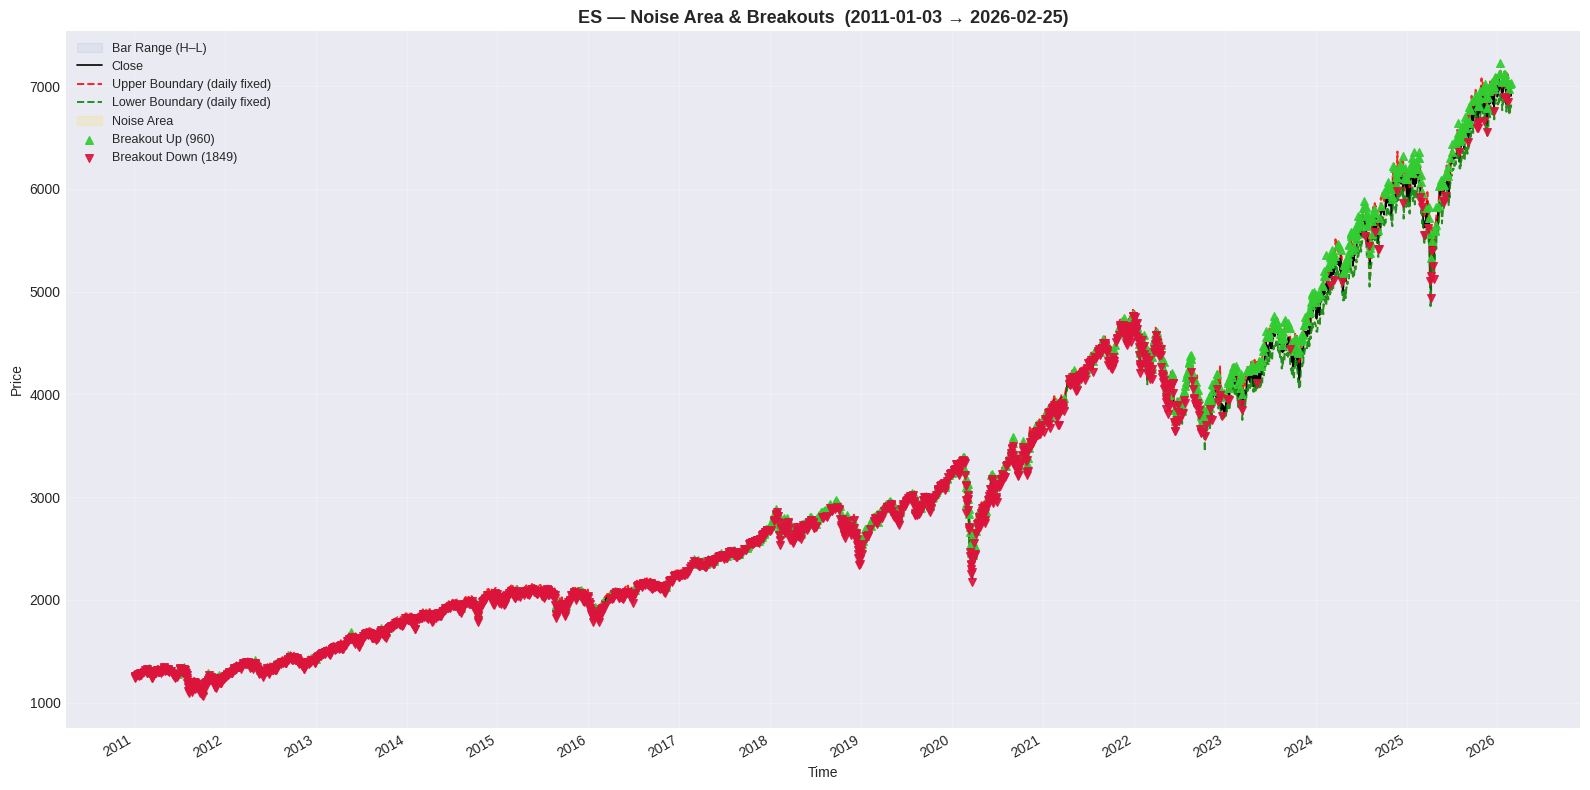

  [NQ] Resampled to 3,892 daily bars for overview chart

Noise area visualization saved to results/NQ_noise_area.png


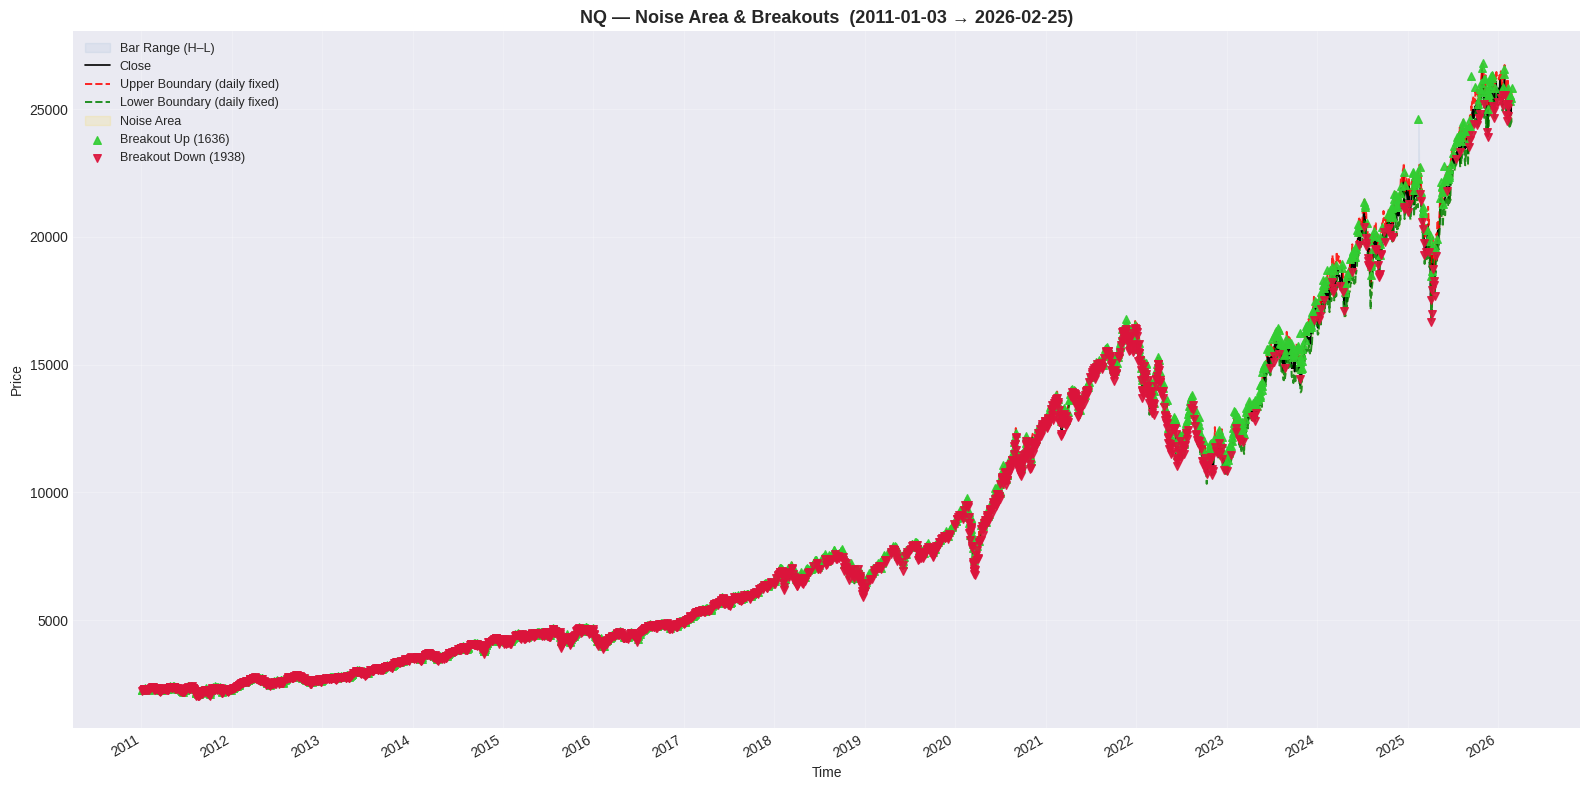

✓ Noise area visualizations created


In [6]:
visualize_noise_area(es_data, 'ES', start_idx=0, end_idx=len(es_data), config=config)
visualize_noise_area(nq_data, 'NQ', start_idx=0, end_idx=len(nq_data))
print("✓ Noise area visualizations created")


## 5. Signal Generation

Generate trading signals based on breakout detection with confirmation and volume filters.

In [7]:
signal_gen = SignalGenerator(config)

print("Generating signals for ES...")
es_data = signal_gen.generate_signals(es_data)

print("Generating signals for NQ...")
nq_data = signal_gen.generate_signals(nq_data)

print("\nSignal generation complete")


Generating signals for ES...
SIGNAL GENERATION
Processing 306523 bars...

Signal Statistics:
  Entry signals: 249
    Long: 249
    Short: 0
  Exit signals: 249
  Exit reasons:
    session_close: 211
    momentum_failure: 25
    trailing_stop: 10
    profit_target: 3
  Avg signal strength: 49.8
Generating signals for NQ...
SIGNAL GENERATION
Processing 306521 bars...

Signal Statistics:
  Entry signals: 799
    Long: 799
    Short: 0
  Exit signals: 799
  Exit reasons:
    session_close: 622
    momentum_failure: 126
    trailing_stop: 39
    profit_target: 8
    new_session: 4
  Avg signal strength: 52.4

Signal generation complete


### Signal Analysis

In [8]:
# ES signal stats
es_entries = es_data[es_data['entry_signal']]
es_exits = es_data[es_data['exit_signal']]

print("="*60)
print("ES SIGNAL STATISTICS")
print("="*60)
print(f"Entry signals: {len(es_entries)}")
print(f"  Long: {(es_entries['signal'] == 1).sum()}")
print(f"  Short: {(es_entries['signal'] == -1).sum()}")
print(f"Exit signals: {len(es_exits)}")
if len(es_exits) > 0:
    print(f"  Exit reasons:")
    for reason, count in es_exits['exit_reason'].value_counts().items():
        print(f"    {reason}: {count}")
print(f"Avg signal strength: {es_entries['signal_strength'].mean():.1f}")

# NQ signal stats
nq_entries = nq_data[nq_data['entry_signal']]
nq_exits = nq_data[nq_data['exit_signal']]

print("\n" + "="*60)
print("NQ SIGNAL STATISTICS")
print("="*60)
print(f"Entry signals: {len(nq_entries)}")
print(f"  Long: {(nq_entries['signal'] == 1).sum()}")
print(f"  Short: {(nq_entries['signal'] == -1).sum()}")
print(f"Exit signals: {len(nq_exits)}")
if len(nq_exits) > 0:
    print(f"  Exit reasons:")
    for reason, count in nq_exits['exit_reason'].value_counts().items():
        print(f"    {reason}: {count}")
print(f"Avg signal strength: {nq_entries['signal_strength'].mean():.1f}")

ES SIGNAL STATISTICS
Entry signals: 249
  Long: 249
  Short: 0
Exit signals: 249
  Exit reasons:
    session_close: 211
    momentum_failure: 25
    trailing_stop: 10
    profit_target: 3
Avg signal strength: 49.8

NQ SIGNAL STATISTICS
Entry signals: 799
  Long: 799
  Short: 0
Exit signals: 799
  Exit reasons:
    session_close: 622
    momentum_failure: 126
    trailing_stop: 39
    profit_target: 8
    new_session: 4
Avg signal strength: 52.4


### Visualize Signals

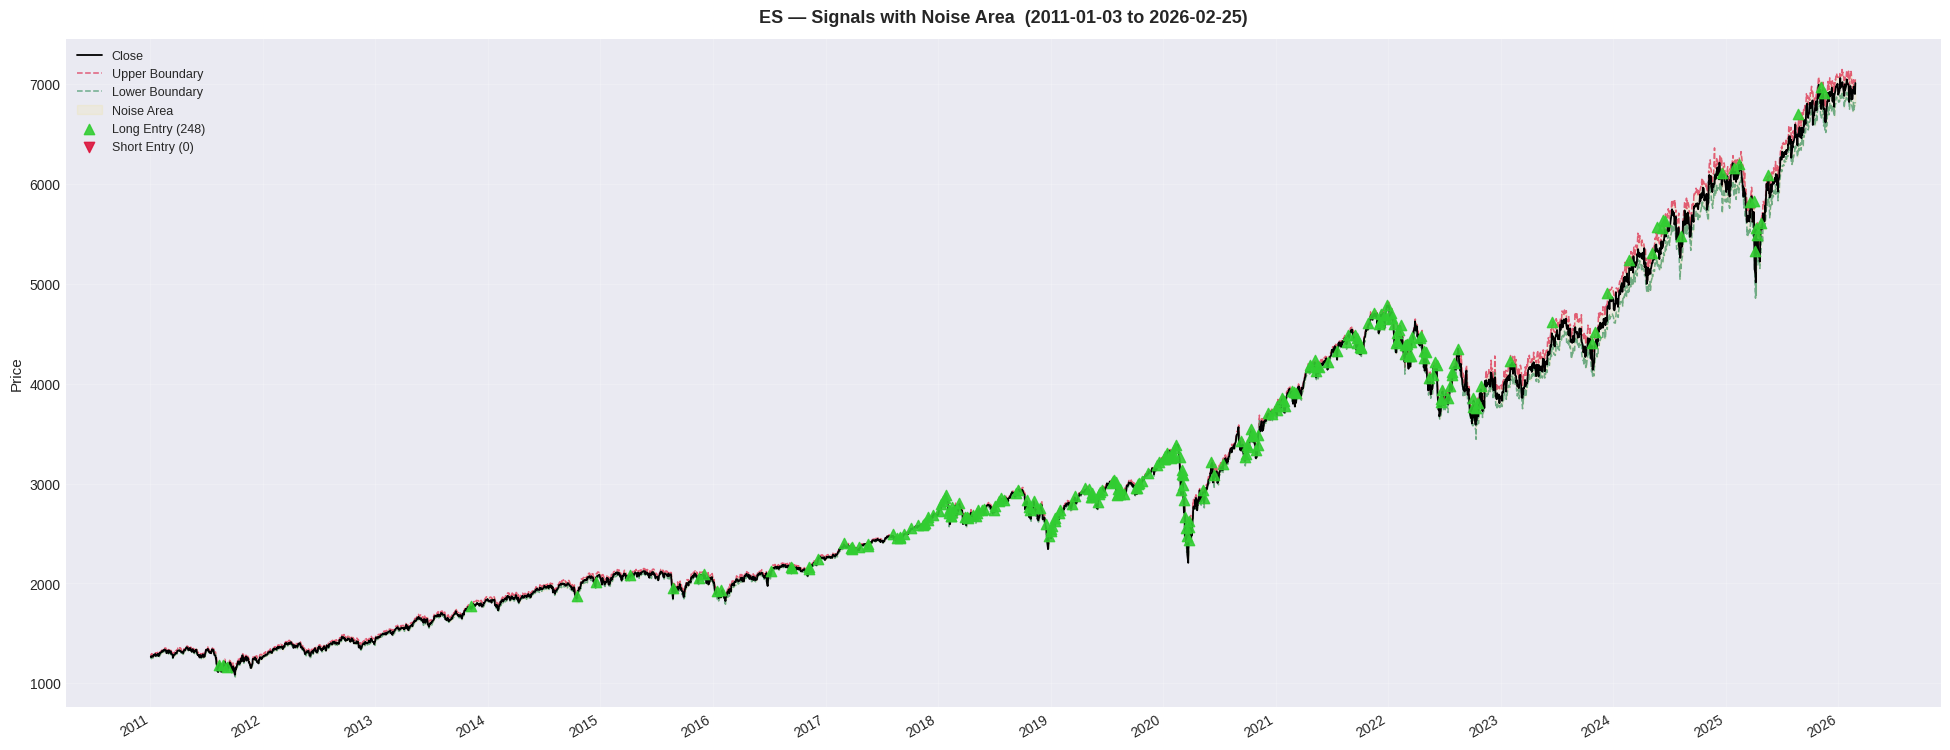

  [ES] 248 long days, 0 short days plotted


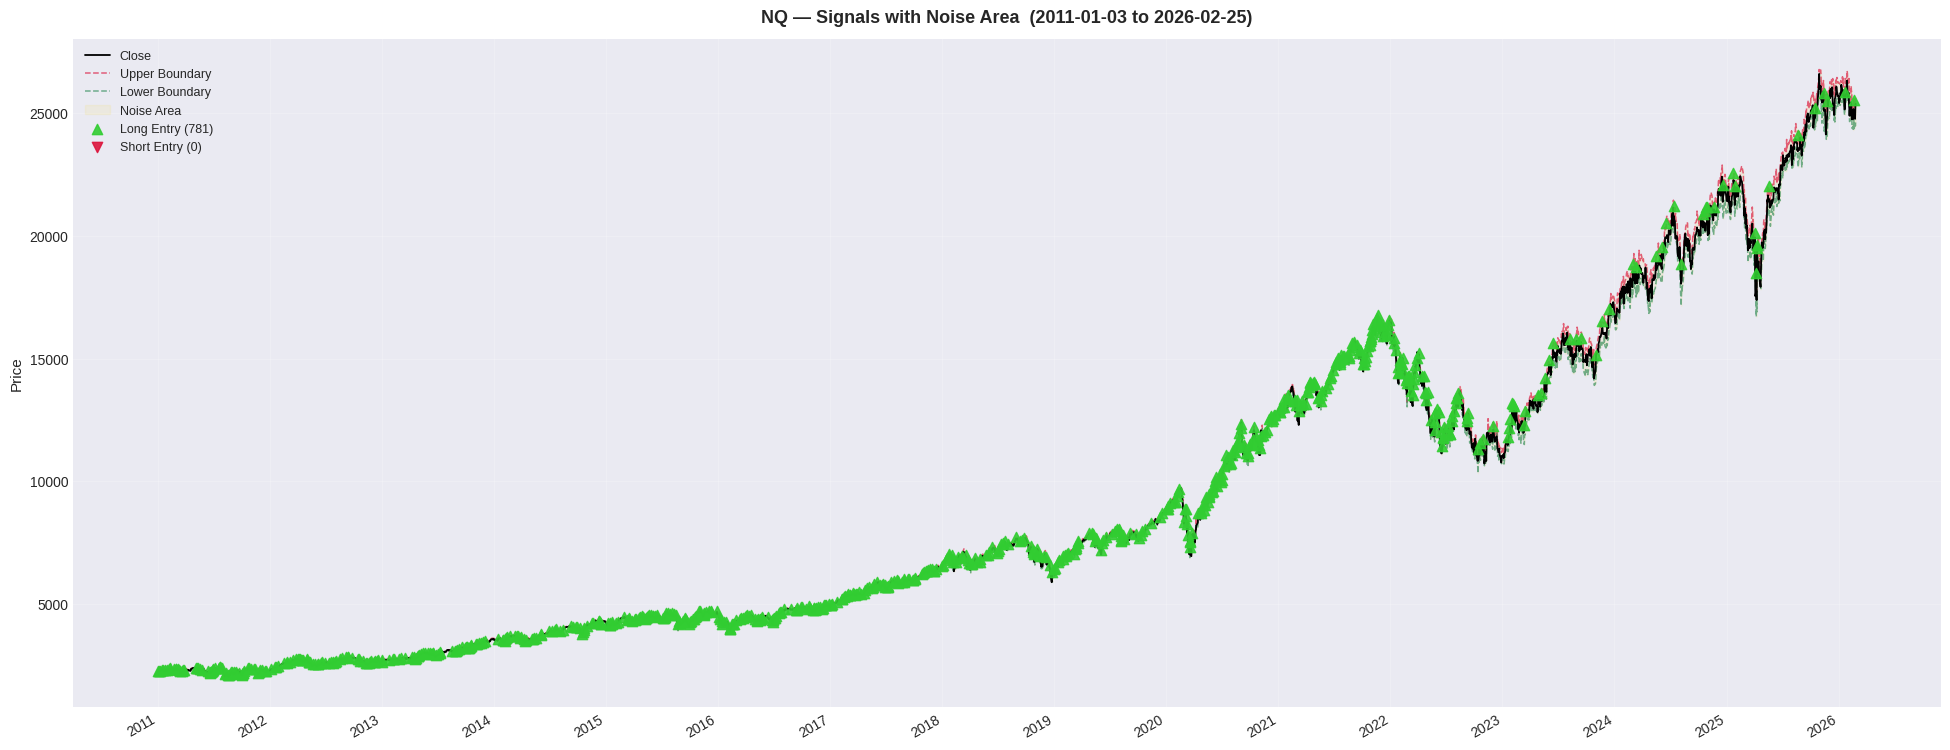

  [NQ] 781 long days, 0 short days plotted
Signal visualizations created


In [9]:
def plot_signals_overview(data, symbol, color):
    """Plot full-history signals chart, resampled to daily for legibility."""
    agg = {
        'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last',
        'upper_boundary': 'mean', 'lower_boundary': 'mean',
        'entry_signal': 'any', 'exit_signal': 'any',
    }
    data['_sig_last'] = data['signal'].where(data['entry_signal'], other=pd.NA).ffill()
    agg['_sig_last'] = 'last'

    daily = data.resample('1B').agg(agg).dropna(subset=['Close'])
    daily['entry_signal'] = daily['entry_signal'].fillna(False)

    fig, ax = plt.subplots(figsize=(20, 8))

    ax.plot(daily.index, daily['Close'], linewidth=1.3, color='black', label='Close', zorder=3)
    ax.plot(daily.index, daily['upper_boundary'], linestyle='--', color='crimson',
            alpha=0.65, linewidth=1.1, label='Upper Boundary')
    ax.plot(daily.index, daily['lower_boundary'], linestyle='--', color='seagreen',
            alpha=0.65, linewidth=1.1, label='Lower Boundary')
    ax.fill_between(daily.index, daily['lower_boundary'], daily['upper_boundary'],
                    alpha=0.08, color='gold', label='Noise Area')

    long_days  = daily[daily['entry_signal'] & (daily['_sig_last'] == 1)]
    short_days = daily[daily['entry_signal'] & (daily['_sig_last'] == -1)]
    ax.scatter(long_days.index,  long_days['High']  * 1.001, marker='^', s=55,
               color='limegreen', label=f'Long Entry ({len(long_days)})', zorder=5, alpha=0.9)
    ax.scatter(short_days.index, short_days['Low'] * 0.999, marker='v', s=55,
               color='crimson',   label=f'Short Entry ({len(short_days)})', zorder=5, alpha=0.9)

    span_days = (daily.index[-1] - daily.index[0]).days
    if span_days > 365 * 2:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
    elif span_days > 180:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

    date_range = f"{daily.index[0].strftime('%Y-%m-%d')} to {daily.index[-1].strftime('%Y-%m-%d')}"
    ax.set_title(f'{symbol} — Signals with Noise Area  ({date_range})',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Price', fontsize=11)
    ax.legend(loc='upper left', fontsize=9, framealpha=0.8)
    ax.grid(True, alpha=0.22)
    fig.autofmt_xdate()
    plt.tight_layout(pad=2.5)
    plt.savefig(f'results/02_{symbol}_signals.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  [{symbol}] {len(long_days)} long days, {len(short_days)} short days plotted")


plot_signals_overview(es_data.copy(), 'ES', 'blue')
plot_signals_overview(nq_data.copy(), 'NQ', 'orange')
print("Signal visualizations created")


## 6. Position Sizing

Calculate position sizes using volatility targeting to maintain 3% daily portfolio volatility.

In [10]:
sizer = PositionSizer(config)
portfolio = sizer.calculate_portfolio_positions(es_data, nq_data)
print("Position sizing complete")

POSITION SIZING
Portfolio value: $2,500,000
Target volatility: 10.0%
Leverage bounds: 1.0x - 8.0x

Calculating volatility...
  ES avg vol: 44.4%
  NQ avg vol: 37.9%

Calculating position sizes...

Position Statistics:
  ES momentum:
    Active bars:    2,915 of 306,523 (1.0%)
    Avg size (when active): 1.2 contracts
    Max size:        4 contracts
    Avg leverage (when active): 0.07x
    Max leverage:    0.21x
  NQ momentum:
    Active bars:    34,349 of 306,521 (11.2%)
    Avg size (when active): 17.5 contracts
    Max size:        50 contracts
    Avg leverage (when active): 0.67x
    Max leverage:    2.81x
  NQ long-only:
    Avg size (when active): 0.0 contracts
    Max size:        0 contracts
    Avg leverage (when active): 0.00x
    Max leverage:    0.00x
Position sizing complete


### Position Size Analysis

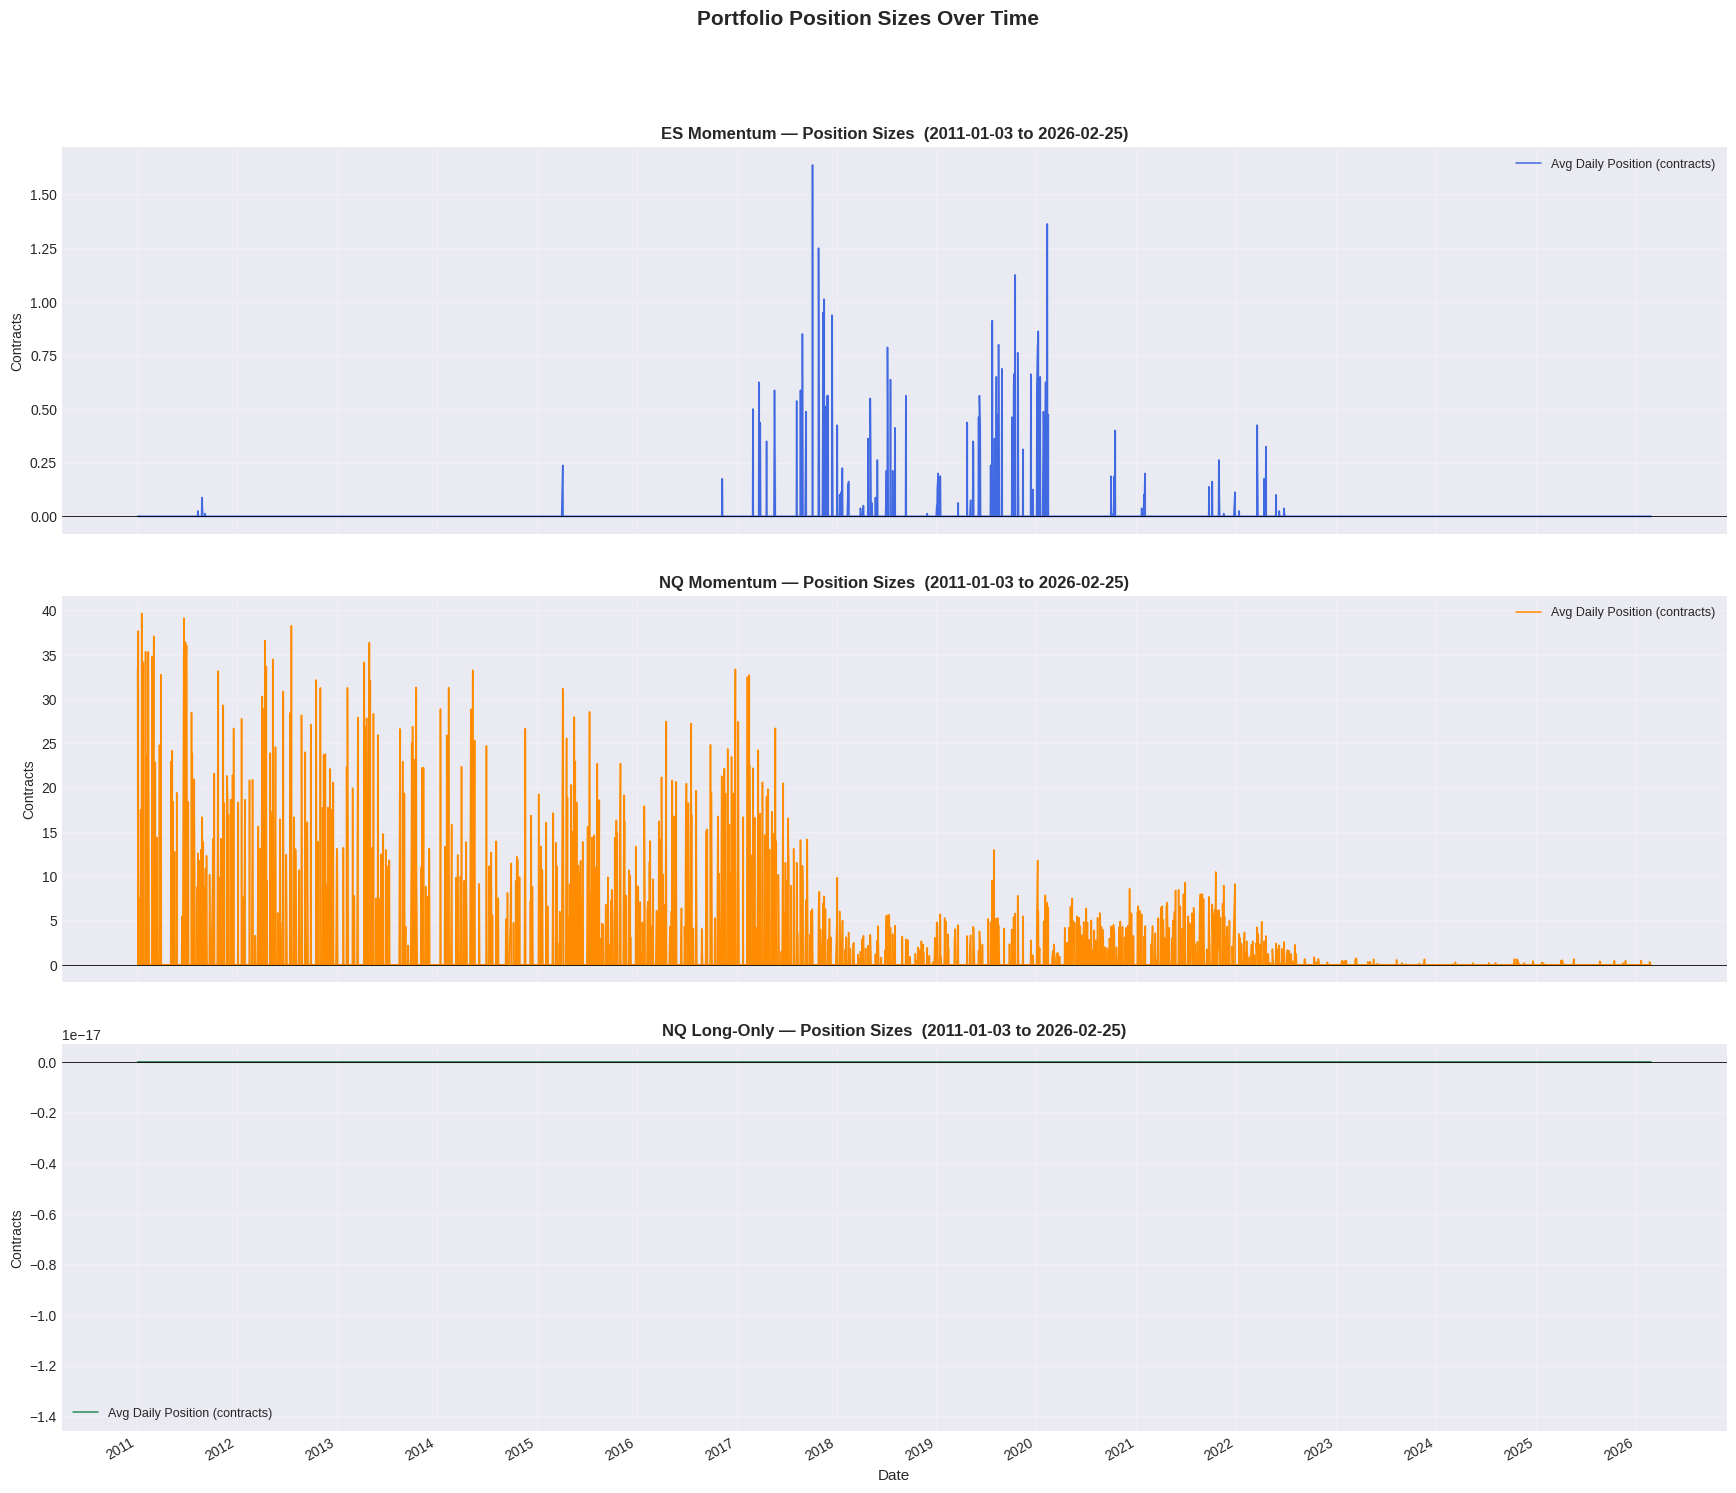

Position size visualization created


In [11]:
def plot_position_sizes(ax, data, label, color):
    """Resample position_size to daily and plot full history."""
    daily = data['position_size'].resample('1B').mean().dropna()
    date_range = f"{daily.index[0].strftime('%Y-%m-%d')} to {daily.index[-1].strftime('%Y-%m-%d')}"
    ax.plot(daily.index, daily, linewidth=1.1, label='Avg Daily Position (contracts)', color=color)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.6)
    ax.fill_between(daily.index, 0, daily, alpha=0.25, color=color)
    ax.set_title(f'{label} — Position Sizes  ({date_range})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Contracts', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    span_days = (daily.index[-1] - daily.index[0]).days
    if span_days > 365 * 2:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
    elif span_days > 180:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))


fig, axes = plt.subplots(3, 1, figsize=(18, 15))
fig.suptitle('Portfolio Position Sizes Over Time', fontsize=15, fontweight='bold', y=1.01)

plot_position_sizes(axes[0], portfolio['ES_momentum'],  'ES Momentum',  'royalblue')
plot_position_sizes(axes[1], portfolio['NQ_momentum'],  'NQ Momentum',  'darkorange')
plot_position_sizes(axes[2], portfolio['NQ_long_only'], 'NQ Long-Only', 'seagreen')
axes[2].set_xlabel('Date', fontsize=11)

fig.autofmt_xdate()
plt.tight_layout(pad=3.0)
plt.savefig('results/03_position_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Position size visualization created")


## 7. Backtesting

Run event-driven backtest with realistic transaction costs (1 tick slippage + commission).

In [12]:
# Reload config to ensure multipliers are current
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

backtester = Backtester(config)
equity_curve = backtester.run_backtest(portfolio)
trades_df = backtester.get_trades_dataframe()

print("Backtesting complete")


BACKTESTING
Initial capital: $2,500,000
Transaction costs:
  Slippage: 0.5 ticks per side
  Commission: $2.00 per contract

Backtesting 306518 bars...

Backtest Complete!
Total trades: 841
Final portfolio value: $2,439,730
Total return: -2.41%

Trade Statistics:
  Winning trades: 420 (49.9%)
  Losing trades: 421 (50.1%)
  Avg win: $4,740
  Avg loss: $-4,753

Total transaction costs: $78,146
  As % of initial capital: 3.13%
Backtesting complete


### Quick Equity Curve Preview

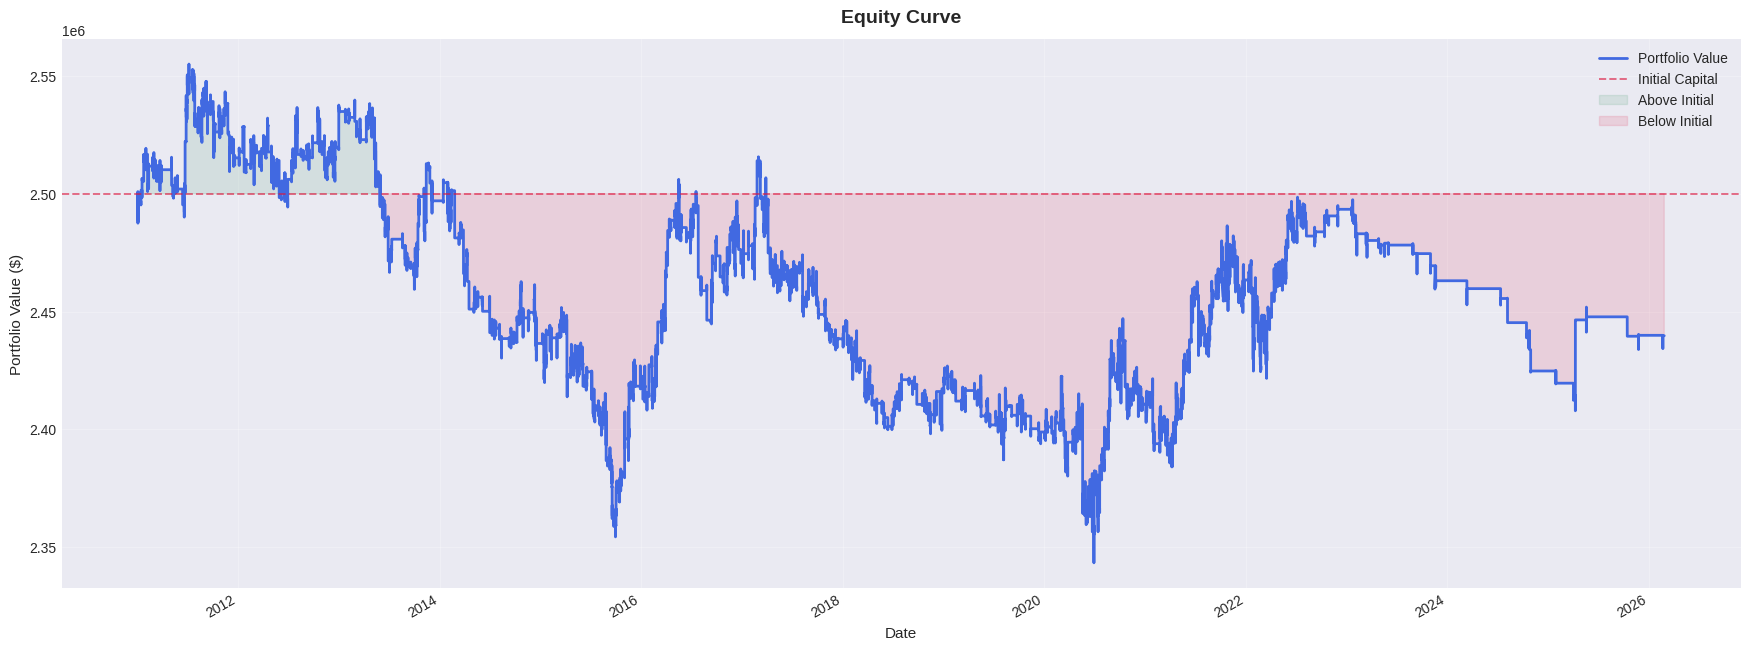

Total Return: -2.41%
Final Portfolio Value: $2,439,730
Total Trades: 841


In [13]:
fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(equity_curve.index, equity_curve['portfolio_value'],
        linewidth=2, color='royalblue', label='Portfolio Value')
ax.axhline(y=config['strategy']['portfolio']['initial_capital'],
           color='crimson', linestyle='--', alpha=0.6, linewidth=1.4, label='Initial Capital')
ax.fill_between(equity_curve.index,
                config['strategy']['portfolio']['initial_capital'],
                equity_curve['portfolio_value'],
                where=equity_curve['portfolio_value'] >= config['strategy']['portfolio']['initial_capital'],
                alpha=0.12, color='seagreen', label='Above Initial')
ax.fill_between(equity_curve.index,
                config['strategy']['portfolio']['initial_capital'],
                equity_curve['portfolio_value'],
                where=equity_curve['portfolio_value'] < config['strategy']['portfolio']['initial_capital'],
                alpha=0.12, color='crimson', label='Below Initial')
ax.set_title('Equity Curve', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Portfolio Value ($)', fontsize=11)
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout(pad=2.5)
plt.savefig('results/04_equity_curve_preview.png', dpi=150, bbox_inches='tight')
plt.show()

total_return = (equity_curve['portfolio_value'].iloc[-1] / equity_curve['portfolio_value'].iloc[0] - 1) * 100
print(f"Total Return: {total_return:.2f}%")
print(f"Final Portfolio Value: ${equity_curve['portfolio_value'].iloc[-1]:,.0f}")
print(f"Total Trades: {len(trades_df)}")


## 8. Performance Evaluation

Calculate comprehensive performance metrics and generate visualizations.

In [14]:
# Initialize evaluator
evaluator = PerformanceEvaluator(config)

# Evaluate performance
metrics = evaluator.evaluate_strategy(equity_curve, trades_df)

print("\n✓ Performance evaluation complete")

PERFORMANCE EVALUATION

Returns:
  Total Return:         -2.41%  (15.15 years)
  CAGR (annualized):    -0.16%
  Annualized Volatility:2.00%  (daily-based)

Risk-Adjusted Metrics:
  Sharpe Ratio:  -0.055  (daily-based)
  Sortino Ratio: -0.036  (daily-based)
  Calmar Ratio:  -0.013  (daily-based)

Drawdown:
  Max Drawdown: -8.29%
  Peak:   2011-07-07 18:30:00+00:00
  Trough: 2020-06-29 19:00:00+00:00

Trade Statistics:
  Total Trades: 841
  Win Rate: 49.9%
  Profit Factor: 0.99
  Average Win: $4,740
  Average Loss: $-4,753
  Expectancy: $-12
  Avg Holding: 46.2 bars

Transaction Costs:
  Total Commission: $22,186
  Total Slippage: $55,960
  Total Costs: $78,146
  Costs as % of Capital: 3.13%

✓ Performance evaluation complete


### Comprehensive Visualizations


Performance visualization saved to results/performance_visualization.png


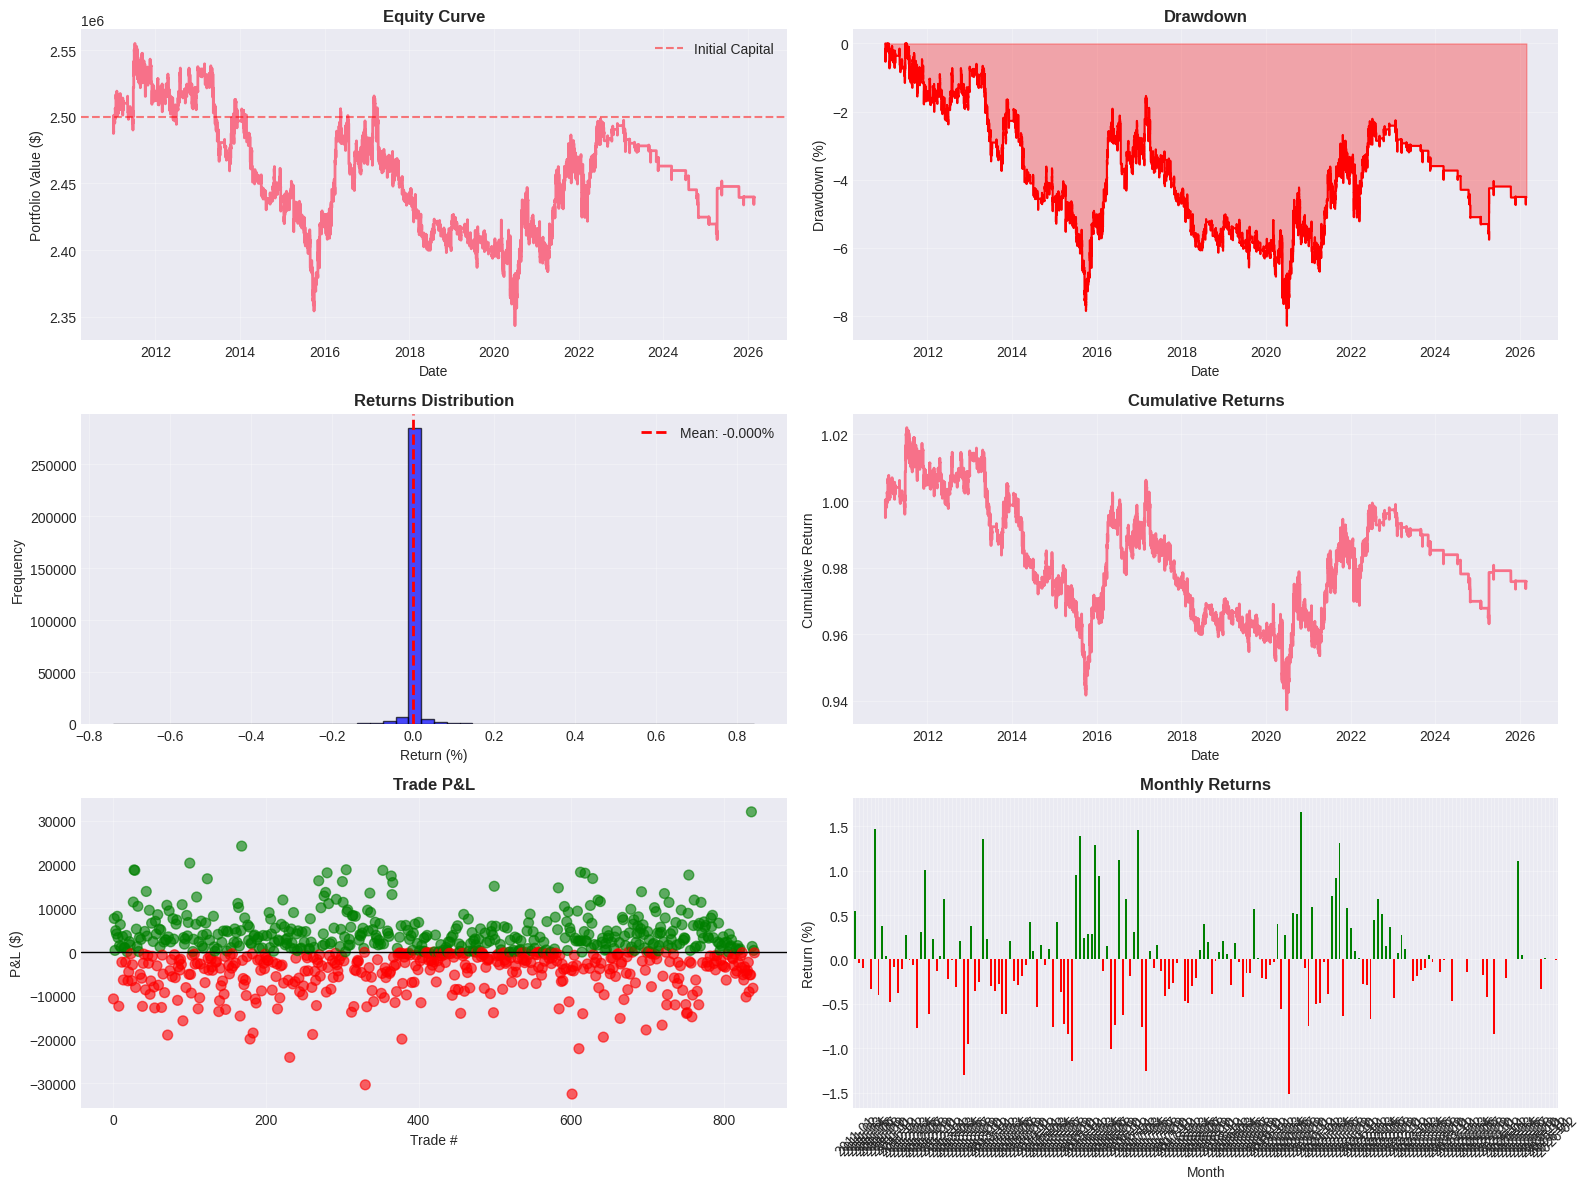

In [15]:
# Generate full performance visualization
visualize_performance(equity_curve, trades_df, metrics)

## 9. Detailed Trade Analysis

TRADE ANALYSIS

Trades by Symbol:
symbol
NQ    784
ES     57
Name: count, dtype: int64

Trades by Side:
side
long    841
Name: count, dtype: int64

Exit Reasons:
exit_reason
session_close       664
momentum_failure    124
trailing_stop        41
profit_target         8
new_session           4
Name: count, dtype: int64

Top 10 Winning Trades:
                timestamp symbol side  pnl_net  holding_bars
2025-04-09 19:55:00+00:00     NQ long  32058.0            35
2013-11-13 20:55:00+00:00     NQ long  24228.0            44
2012-07-27 19:55:00+00:00     NQ long  20339.0            42
2016-03-29 19:55:00+00:00     NQ long  18825.0            43
2011-06-23 19:55:00+00:00     NQ long  18796.0            37
2016-12-07 20:55:00+00:00     NQ long  18699.0            36
2011-06-27 18:30:00+00:00     NQ long  18690.0            53
2020-07-01 13:25:00+00:00     NQ long  18264.0           281
2015-11-18 20:55:00+00:00     NQ long  18124.0            49
2020-07-20 19:25:00+00:00     NQ long  18040.0

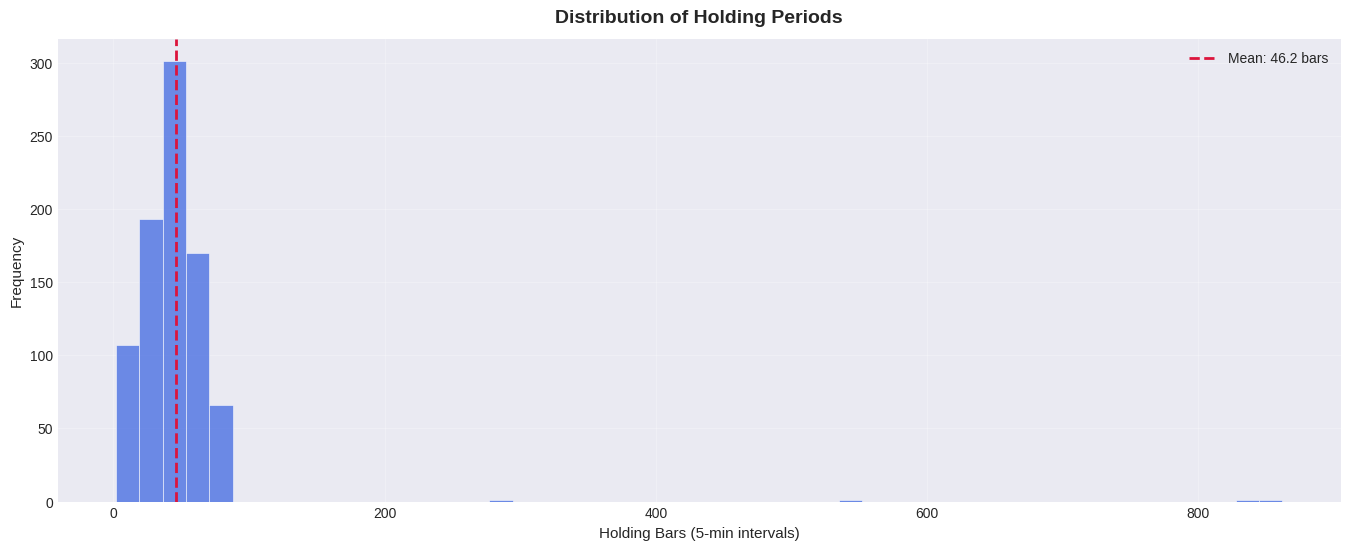

In [16]:
if len(trades_df) > 0:
    print("=" * 60)
    print("TRADE ANALYSIS")
    print("=" * 60)

    print("\nTrades by Symbol:")
    print(trades_df['symbol'].value_counts())

    print("\nTrades by Side:")
    print(trades_df['side'].value_counts())

    print("\nExit Reasons:")
    print(trades_df['exit_reason'].value_counts())

    print("\nTop 10 Winning Trades:")
    top_winners = trades_df.nlargest(10, 'pnl_net')[['timestamp', 'symbol', 'side', 'pnl_net', 'holding_bars']]
    print(top_winners.to_string(index=False))

    print("\nTop 10 Losing Trades:")
    top_losers = trades_df.nsmallest(10, 'pnl_net')[['timestamp', 'symbol', 'side', 'pnl_net', 'holding_bars']]
    print(top_losers.to_string(index=False))

    mean_bars = trades_df['holding_bars'].mean()
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.hist(trades_df['holding_bars'], bins=50, alpha=0.75, color='royalblue', edgecolor='white', linewidth=0.5)
    ax.axvline(x=mean_bars, color='crimson', linestyle='--', linewidth=2,
               label=f'Mean: {mean_bars:.1f} bars')
    ax.set_title('Distribution of Holding Periods', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Holding Bars (5-min intervals)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=10, framealpha=0.8)
    ax.grid(True, alpha=0.25)
    plt.tight_layout(pad=2.5)
    plt.savefig('results/05_holding_periods.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No trades executed")


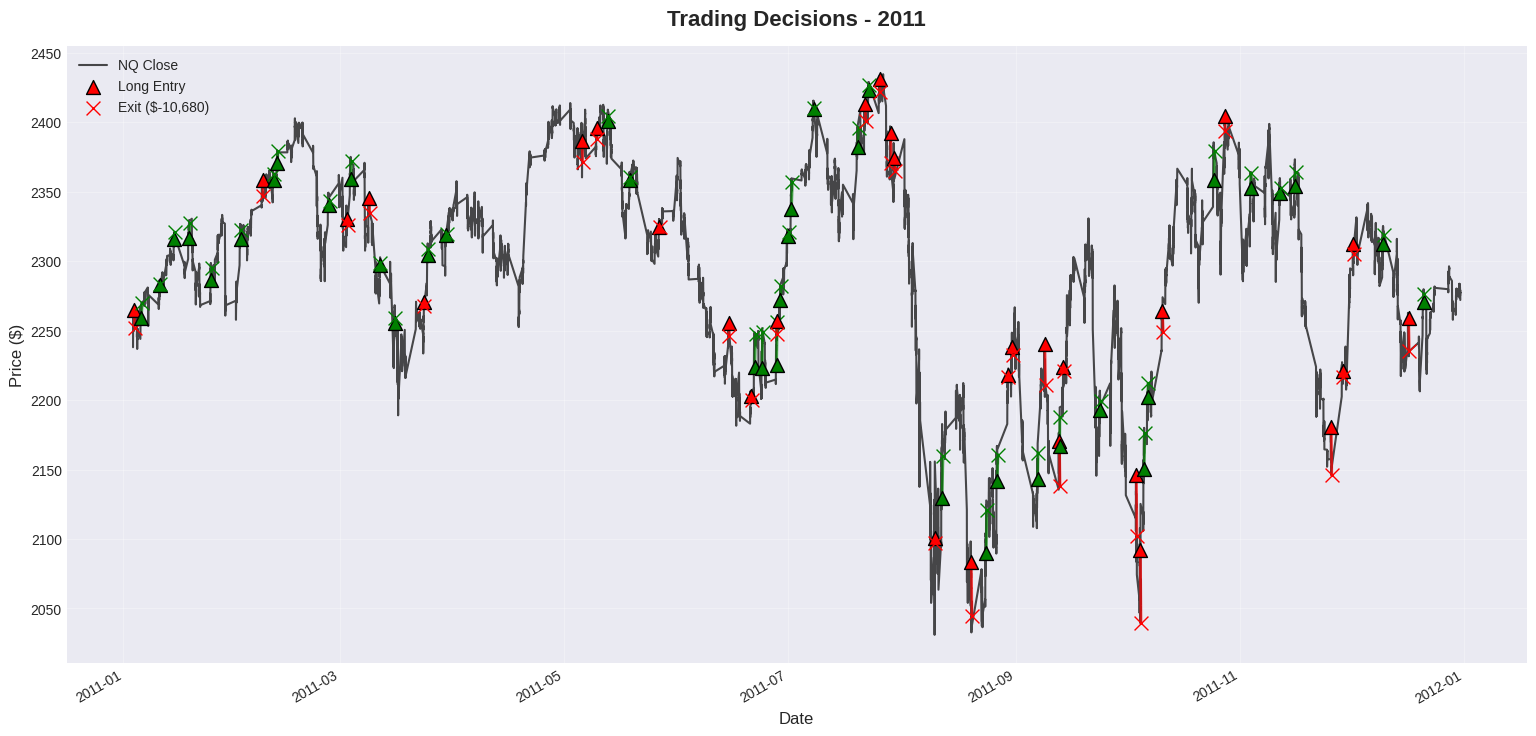


2011 Trades:
  2011-01-03 20:55 NQ long -> $-10,680 (session_close, 55 bars)
  2011-01-05 20:55 NQ long -> $7,696 (session_close, 62 bars)
  2011-01-10 20:55 NQ long -> $400 (session_close, 12 bars)
  2011-01-14 20:55 NQ long -> $4,900 (session_close, 28 bars)
  2011-01-18 20:55 NQ long -> $4,160 (session_close, 75 bars)
  2011-01-24 20:55 NQ long -> $8,188 (session_close, 55 bars)
  2011-02-01 20:55 NQ long -> $3,321 (session_close, 63 bars)
  2011-02-07 20:55 NQ long -> $-12,350 (session_close, 38 bars)
  2011-02-10 20:55 NQ long -> $1,482 (session_close, 68 bars)
  2011-02-11 20:55 NQ long -> $6,320 (session_close, 59 bars)
  2011-02-25 20:55 NQ long -> $1,056 (session_close, 71 bars)
  2011-03-02 20:55 NQ long -> $-2,300 (session_close, 64 bars)
  2011-03-03 20:55 NQ long -> $3,542 (session_close, 74 bars)
  2011-03-08 20:55 NQ long -> $-6,356 (session_close, 49 bars)
  2011-03-11 20:55 NQ long -> $1,036 (session_close, 19 bars)
  2011-03-15 19:55 NQ long -> $1,020 (session_close,

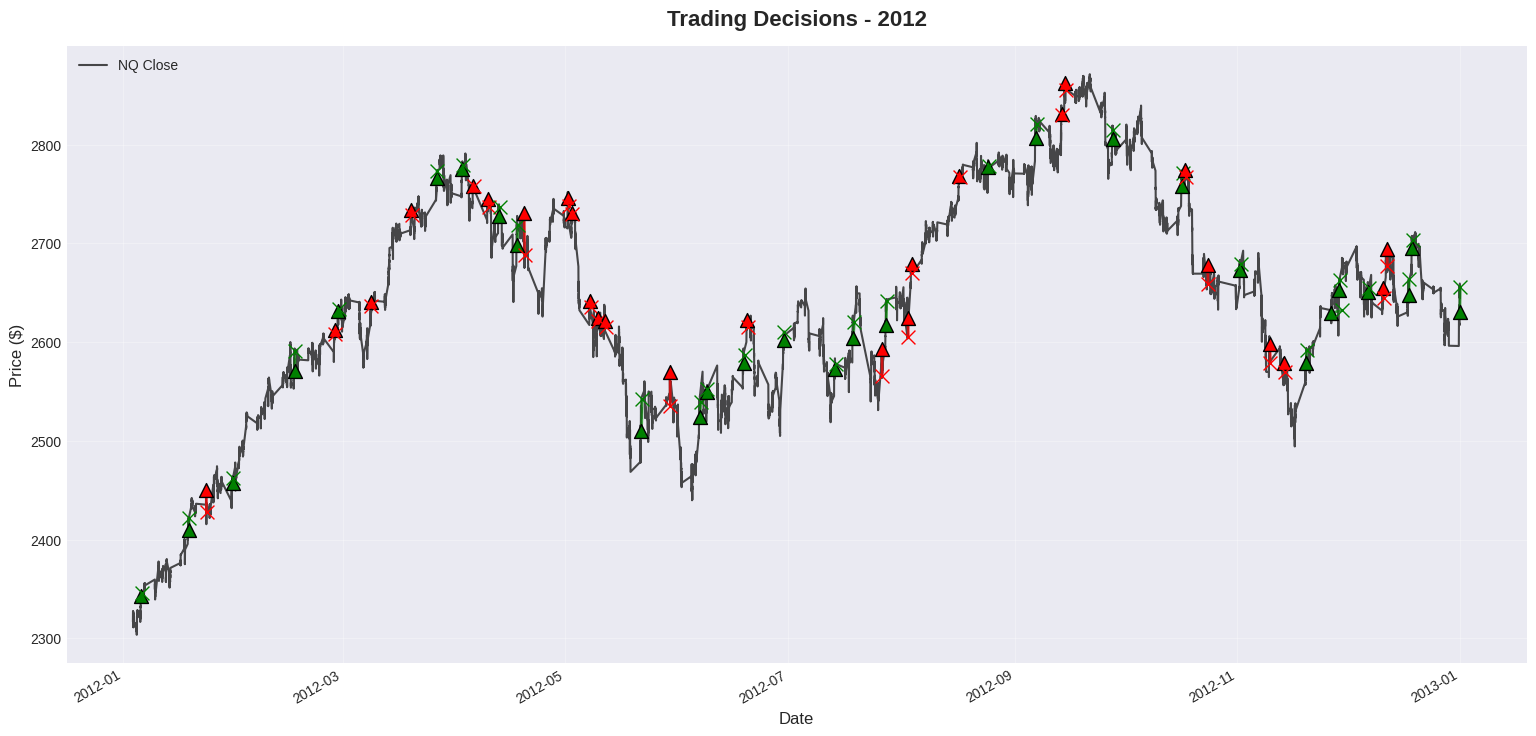


2012 Trades:
  2012-01-05 20:55 NQ long -> $2,784 (session_close, 30 bars)
  2012-01-18 20:55 NQ long -> $10,718 (session_close, 45 bars)
  2012-01-23 16:35 NQ long -> $-18,942 (trailing_stop, 19 bars)
  2012-01-30 20:55 NQ long -> $3,486 (session_close, 31 bars)
  2012-02-16 20:55 NQ long -> $9,432 (session_close, 48 bars)
  2012-02-27 20:55 NQ long -> $-4,232 (session_close, 37 bars)
  2012-02-28 20:55 NQ long -> $2,352 (session_close, 38 bars)
  2012-03-08 20:55 NQ long -> $-1,722 (session_close, 12 bars)
  2012-03-19 19:55 NQ long -> $-5,600 (session_close, 25 bars)
  2012-03-26 19:55 NQ long -> $7,650 (session_close, 21 bars)
  2012-04-02 19:55 NQ long -> $2,988 (session_close, 50 bars)
  2012-04-05 19:55 NQ long -> $-588 (session_close, 47 bars)
  2012-04-09 19:55 NQ long -> $-5,832 (session_close, 38 bars)
  2012-04-12 19:55 NQ long -> $6,408 (session_close, 66 bars)
  2012-04-17 19:55 NQ long -> $7,344 (session_close, 68 bars)
  2012-04-19 17:55 NQ long -> $-11,011 (trailing_s

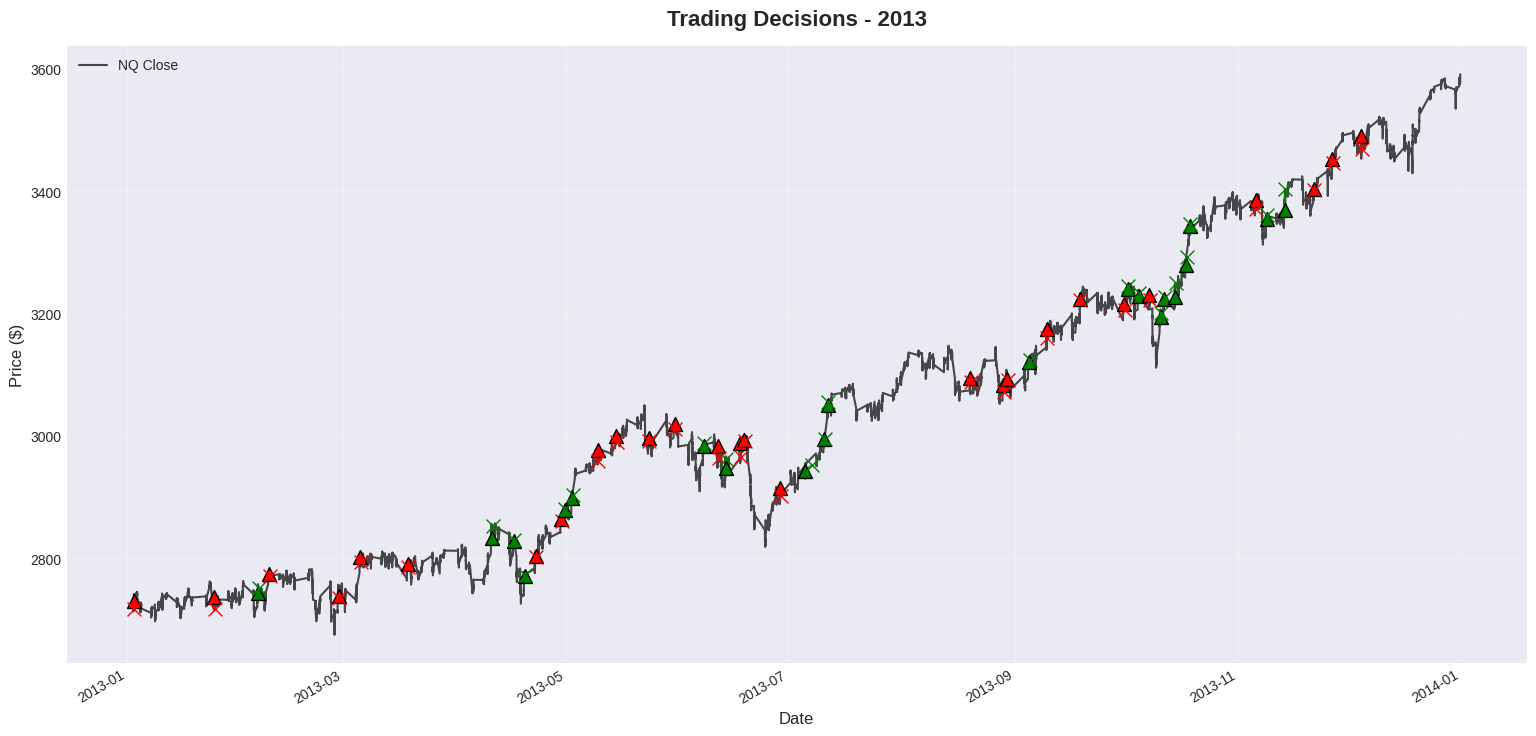


2013 Trades:
  2013-01-02 18:45 NQ long -> $-1,410 (momentum_failure, 50 bars)
  2013-01-24 19:10 NQ long -> $-4,120 (momentum_failure, 50 bars)
  2013-02-05 20:55 NQ long -> $2,754 (session_close, 45 bars)
  2013-02-08 20:55 NQ long -> $-930 (session_close, 73 bars)
  2013-02-27 20:55 NQ long -> $-1,640 (session_close, 59 bars)
  2013-03-05 20:55 NQ long -> $-3,340 (session_close, 29 bars)
  2013-03-18 19:55 NQ long -> $-4,144 (session_close, 47 bars)
  2013-04-10 19:55 NQ long -> $8,206 (session_close, 70 bars)
  2013-04-16 19:55 NQ long -> $1,204 (session_close, 49 bars)
  2013-04-19 19:55 NQ long -> $192 (session_close, 58 bars)
  2013-04-22 19:55 NQ long -> $-2,337 (session_close, 19 bars)
  2013-04-29 19:55 NQ long -> $-2,142 (session_close, 67 bars)
  2013-04-30 19:55 NQ long -> $759 (session_close, 36 bars)
  2013-05-02 19:55 NQ long -> $4,068 (session_close, 57 bars)
  2013-05-09 19:55 NQ long -> $-13,579 (session_close, 27 bars)
  2013-05-14 19:00 NQ long -> $-11,100 (moment

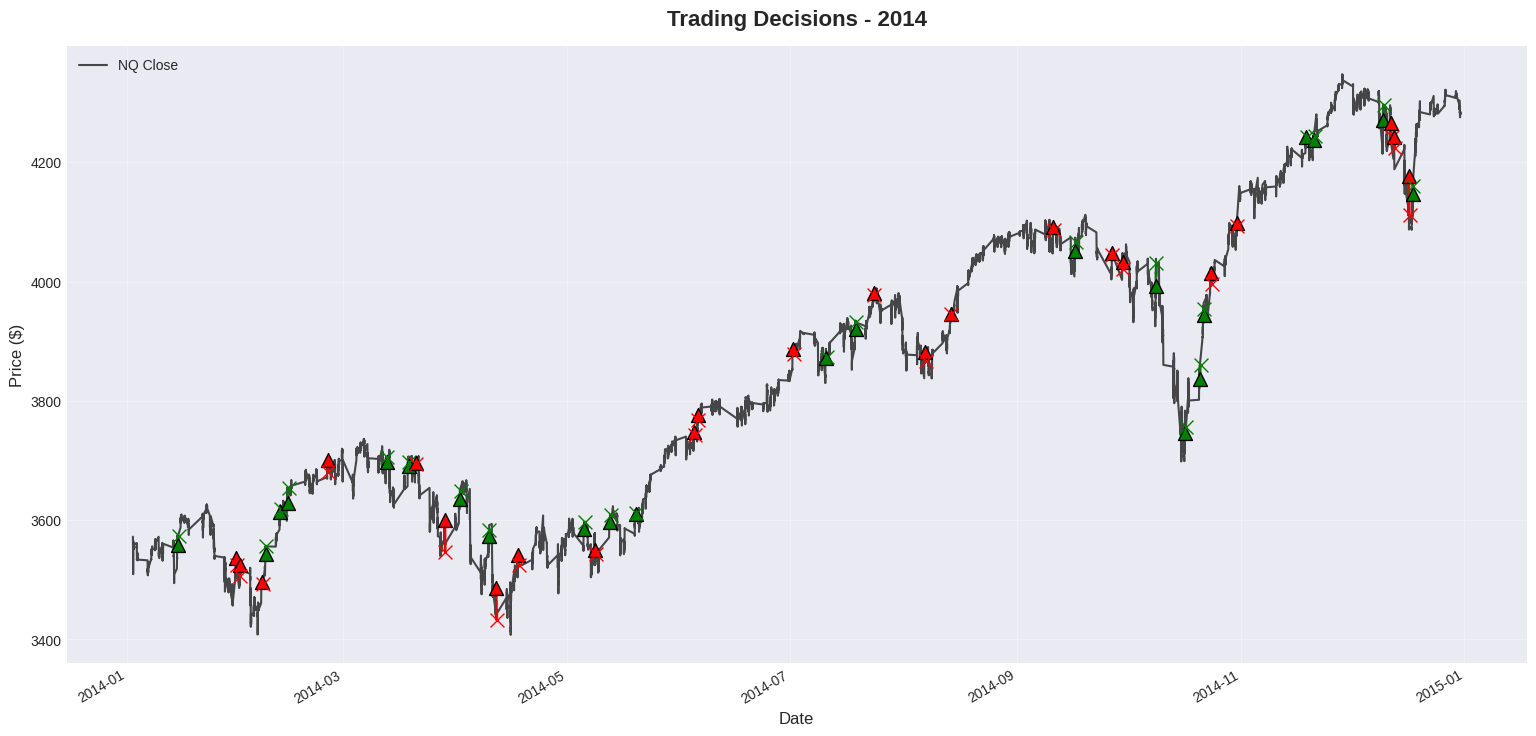


2014 Trades:
  2014-01-14 20:55 NQ long -> $7,825 (session_close, 56 bars)
  2014-01-30 20:55 NQ long -> $-6,399 (session_close, 39 bars)
  2014-01-31 20:55 NQ long -> $-9,909 (session_close, 26 bars)
  2014-02-06 20:55 NQ long -> $-1,054 (session_close, 63 bars)
  2014-02-07 20:55 NQ long -> $6,188 (session_close, 33 bars)
  2014-02-11 20:55 NQ long -> $2,701 (session_close, 33 bars)
  2014-02-13 20:55 NQ long -> $5,736 (session_close, 70 bars)
  2014-02-24 20:55 NQ long -> $-19,850 (session_close, 29 bars)
  2014-03-12 19:55 NQ long -> $2,054 (session_close, 55 bars)
  2014-03-18 19:55 NQ long -> $1,920 (session_close, 61 bars)
  2014-03-20 19:55 NQ long -> $-384 (session_close, 44 bars)
  2014-03-28 18:15 NQ long -> $-18,479 (trailing_stop, 41 bars)
  2014-04-01 19:55 NQ long -> $3,682 (session_close, 71 bars)
  2014-04-09 19:55 NQ long -> $3,924 (session_close, 21 bars)
  2014-04-11 18:45 NQ long -> $-10,720 (trailing_stop, 46 bars)
  2014-04-17 19:55 NQ long -> $-11,620 (session_

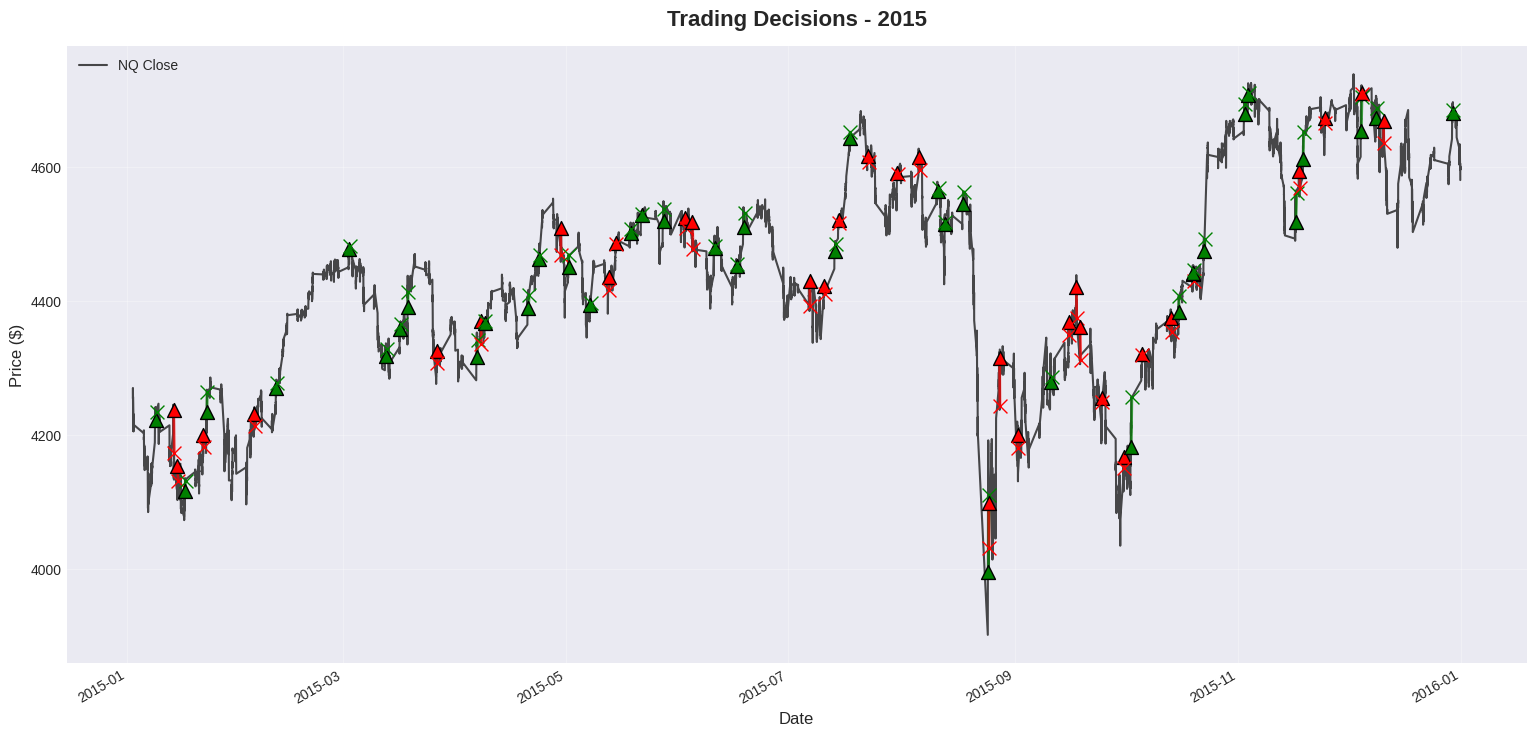


2015 Trades:
  2015-01-08 20:55 NQ long -> $2,508 (session_close, 62 bars)
  2015-01-13 18:30 NQ long -> $-10,456 (trailing_stop, 45 bars)
  2015-01-14 19:15 NQ long -> $-3,164 (momentum_failure, 50 bars)
  2015-01-16 20:55 NQ long -> $6,363 (session_close, 37 bars)
  2015-01-21 20:10 NQ long -> $-2,936 (momentum_failure, 52 bars)
  2015-01-22 20:55 NQ long -> $11,928 (session_close, 20 bars)
  2015-02-04 20:45 NQ long -> $-7,068 (momentum_failure, 51 bars)
  2015-02-10 20:55 NQ long -> $5,814 (session_close, 17 bars)
  2015-03-02 20:55 NQ long -> $1,672 (session_close, 53 bars)
  2015-03-12 19:55 NQ long -> $2,899 (session_close, 75 bars)
  2015-03-16 19:55 NQ long -> $1,995 (session_close, 54 bars)
  2015-03-18 19:55 NQ long -> $3,136 (session_close, 22 bars)
  2015-03-26 19:55 NQ long -> $-6,409 (session_close, 27 bars)
  2015-04-06 19:55 NQ long -> $4,707 (session_close, 74 bars)
  2015-04-07 19:55 NQ long -> $-24,045 (session_close, 47 bars)
  2015-04-08 19:55 NQ long -> $1,007 (

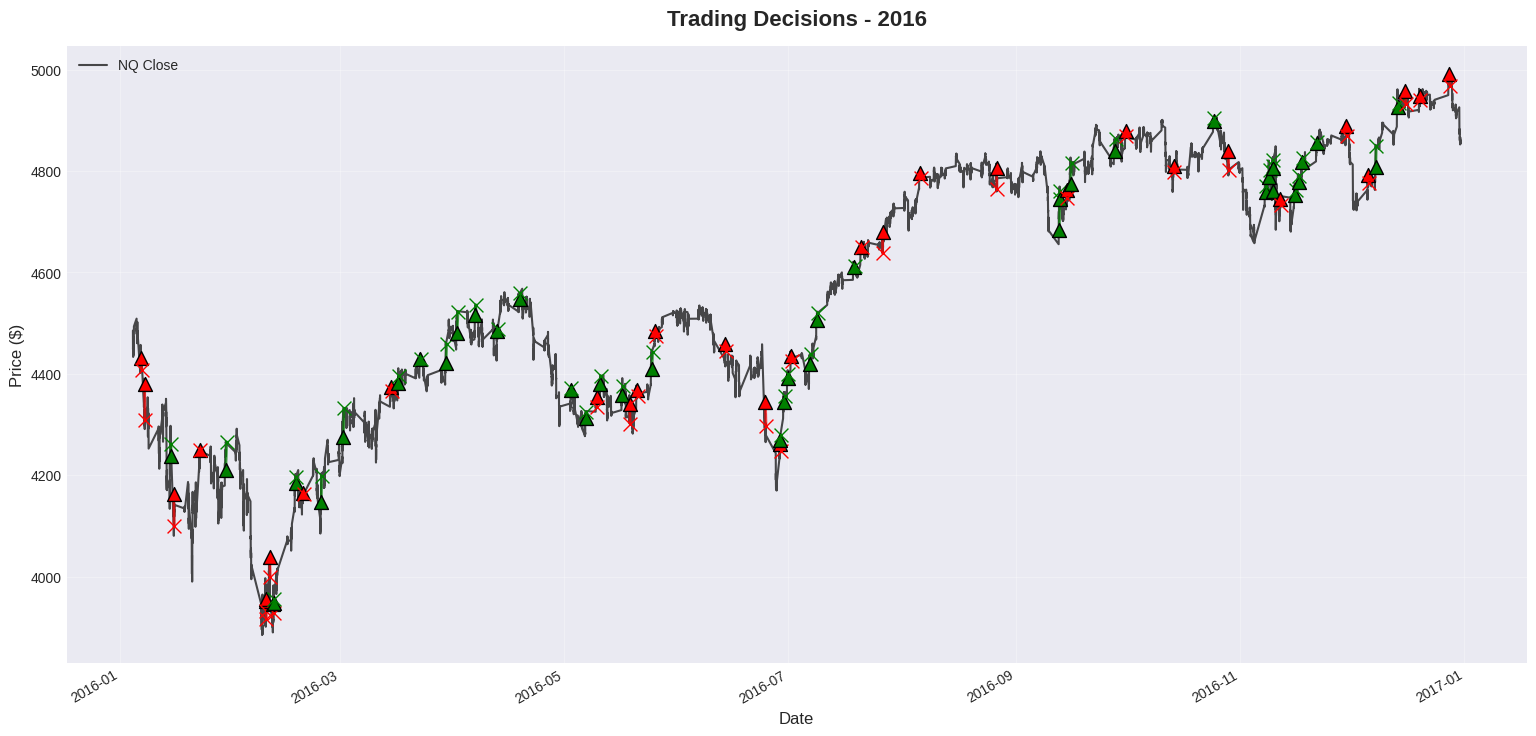


2016 Trades:
  2016-01-06 19:45 NQ long -> $-1,908 (momentum_failure, 60 bars)
  2016-01-07 18:30 NQ long -> $-5,788 (trailing_stop, 36 bars)
  2016-01-14 20:55 NQ long -> $5,496 (session_close, 41 bars)
  2016-01-15 17:15 NQ long -> $-2,504 (trailing_stop, 31 bars)
  2016-01-22 20:55 NQ long -> $-252 (session_close, 20 bars)
  2016-01-29 20:55 NQ long -> $12,078 (session_close, 74 bars)
  2016-02-09 18:50 NQ long -> $-2,888 (momentum_failure, 50 bars)
  2016-02-09 20:55 NQ long -> $-4,293 (session_close, 16 bars)
  2016-02-10 19:40 NQ long -> $-5,614 (momentum_failure, 50 bars)
  2016-02-11 19:05 NQ long -> $-1,785 (momentum_failure, 50 bars)
  2016-02-11 20:55 NQ long -> $1,287 (session_close, 14 bars)
  2016-02-17 20:55 NQ long -> $5,208 (session_close, 43 bars)
  2016-02-19 20:55 NQ long -> $-804 (session_close, 54 bars)
  2016-02-24 20:55 NQ long -> $16,128 (session_close, 24 bars)
  2016-03-01 20:55 NQ long -> $11,380 (session_close, 65 bars)
  2016-03-14 19:55 NQ long -> $-1,98

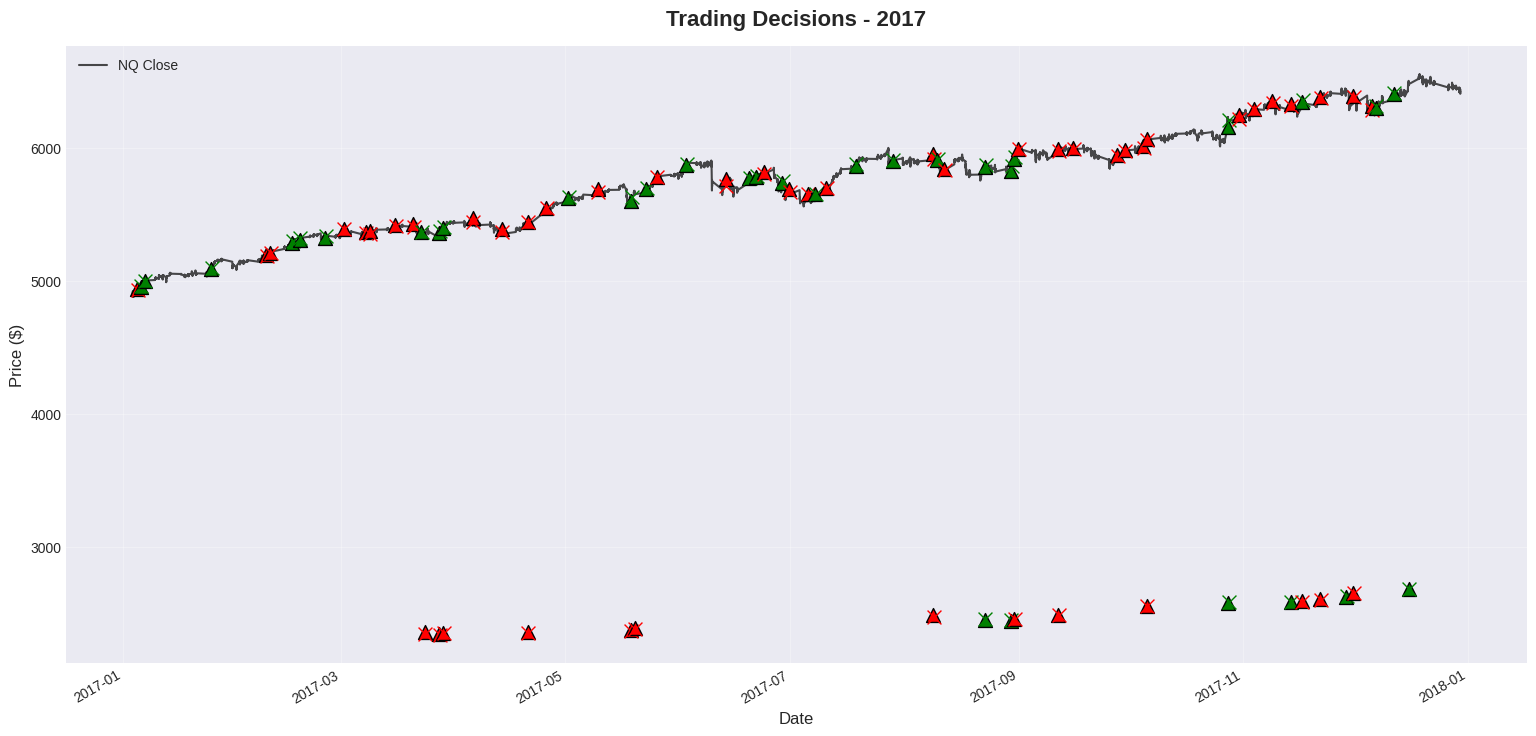


2017 Trades:
  2017-01-04 20:55 NQ long -> $-4,480 (session_close, 18 bars)
  2017-01-05 20:55 NQ long -> $4,841 (session_close, 20 bars)
  2017-01-06 20:55 NQ long -> $4,305 (session_close, 51 bars)
  2017-01-24 20:55 NQ long -> $3,588 (session_close, 27 bars)
  2017-02-08 20:55 NQ long -> $-4,850 (session_close, 20 bars)
  2017-02-09 20:55 NQ long -> $-4,445 (session_close, 55 bars)
  2017-02-15 20:55 NQ long -> $17,400 (session_close, 56 bars)
  2017-02-17 20:55 NQ long -> $13,150 (session_close, 36 bars)
  2017-02-24 20:55 NQ long -> $15,900 (session_close, 20 bars)
  2017-03-01 20:55 NQ long -> $-1,140 (session_close, 47 bars)
  2017-03-07 19:30 NQ long -> $-3,108 (momentum_failure, 50 bars)
  2017-03-08 20:30 NQ long -> $-11,513 (momentum_failure, 54 bars)
  2017-03-15 19:55 NQ long -> $-2,828 (session_close, 22 bars)
  2017-03-20 18:30 NQ long -> $-9,016 (momentum_failure, 50 bars)
  2017-03-22 19:55 NQ long -> $882 (session_close, 56 bars)
  2017-03-23 19:25 ES long -> $-677 (

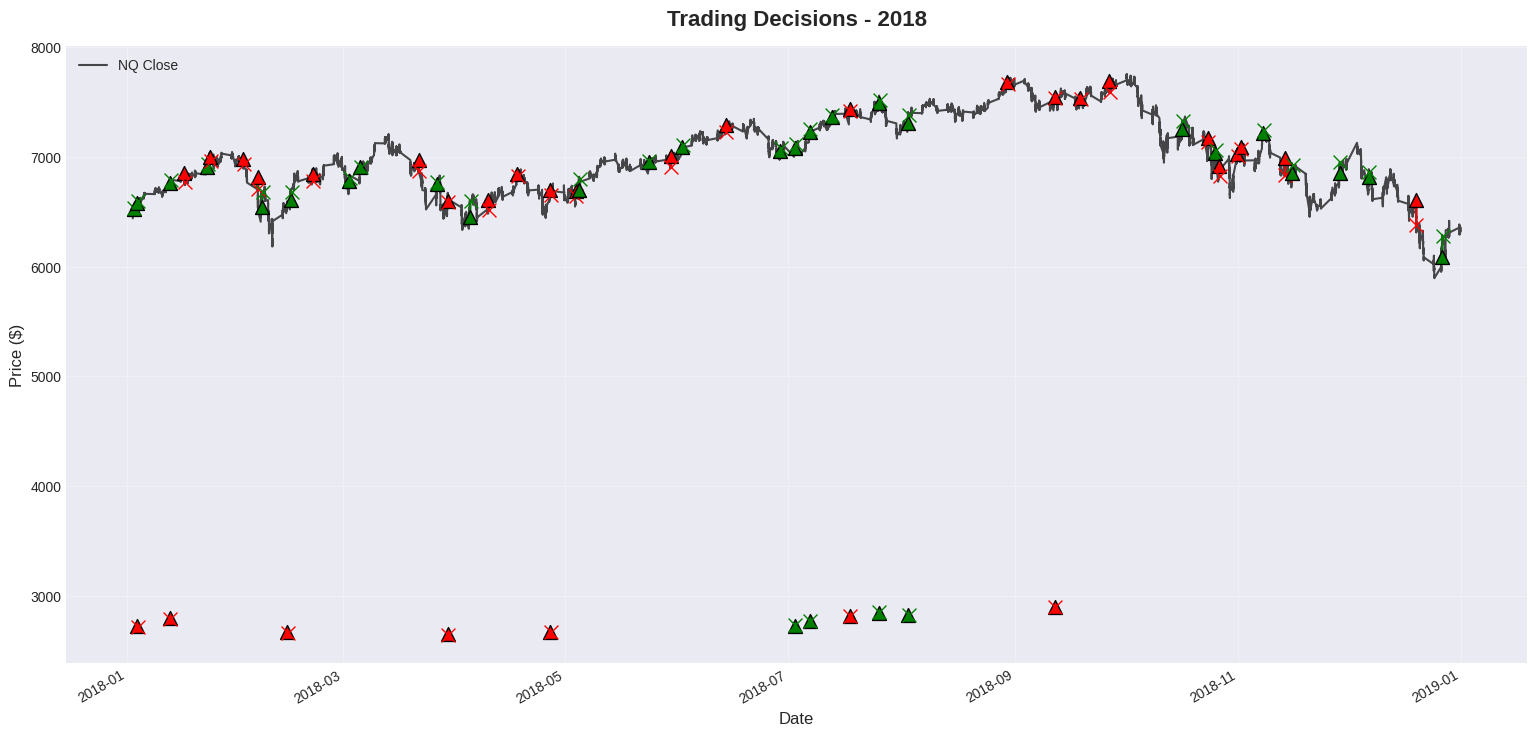


2018 Trades:
  2018-01-02 20:55 NQ long -> $2,344 (session_close, 31 bars)
  2018-01-03 20:55 ES long -> $-264 (session_close, 37 bars)
  2018-01-03 20:55 NQ long -> $2,328 (session_close, 72 bars)
  2018-01-12 20:55 ES long -> $-352 (session_close, 12 bars)
  2018-01-12 20:55 NQ long -> $3,416 (session_close, 39 bars)
  2018-01-16 18:00 NQ long -> $-9,852 (trailing_stop, 35 bars)
  2018-01-22 20:55 NQ long -> $3,858 (session_close, 64 bars)
  2018-01-23 20:15 NQ long -> $-1,154 (momentum_failure, 51 bars)
  2018-02-01 20:55 NQ long -> $-5,235 (session_close, 27 bars)
  2018-02-05 19:20 NQ long -> $-8,528 (momentum_failure, 50 bars)
  2018-02-06 20:55 NQ long -> $5,326 (session_close, 72 bars)
  2018-02-13 20:55 ES long -> $-314 (session_close, 21 bars)
  2018-02-14 20:55 NQ long -> $6,032 (session_close, 67 bars)
  2018-02-20 20:55 NQ long -> $-8,519 (session_close, 30 bars)
  2018-03-02 20:55 NQ long -> $1,869 (session_close, 47 bars)
  2018-03-05 20:55 NQ long -> $192 (session_clos

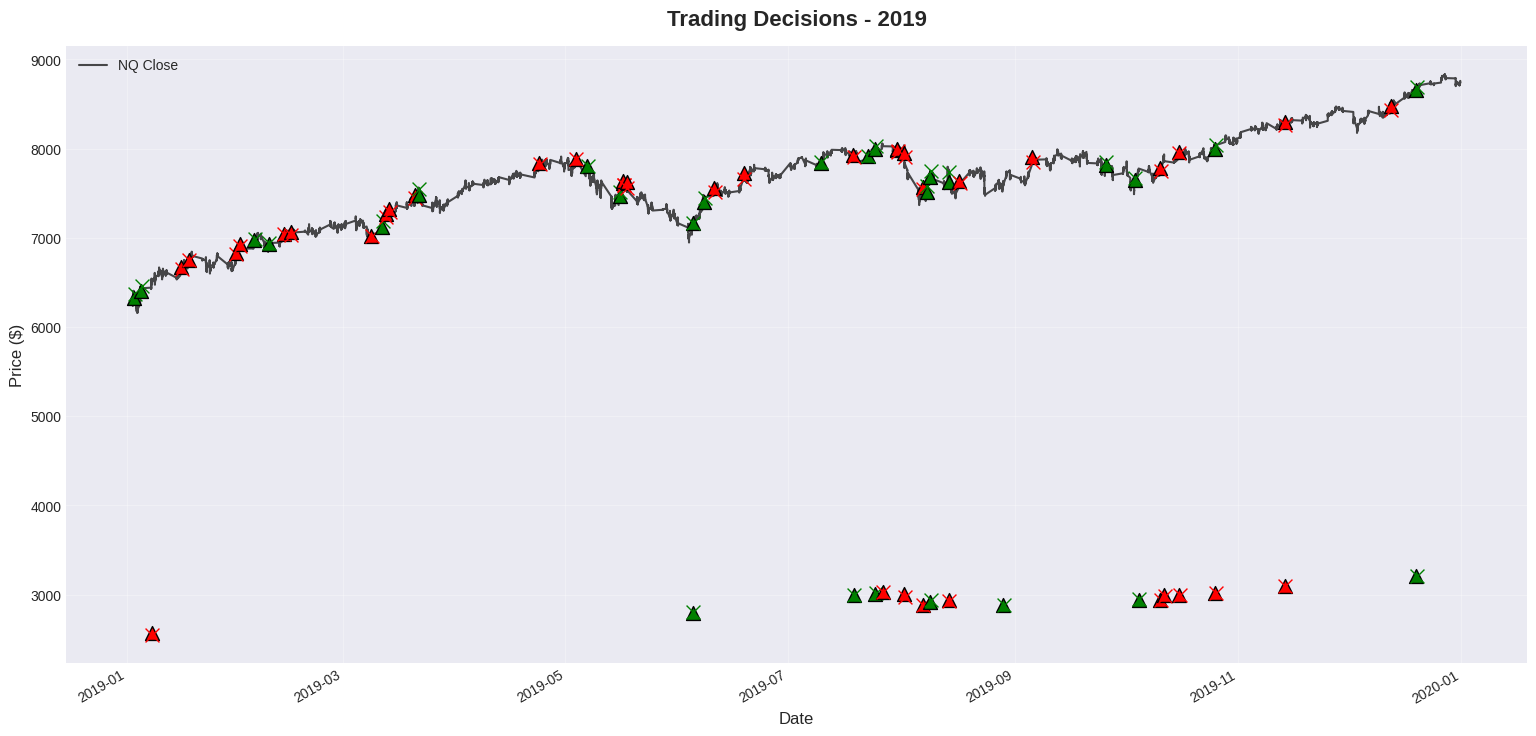


2019 Trades:
  2019-01-02 20:55 NQ long -> $2,889 (session_close, 66 bars)
  2019-01-04 20:55 NQ long -> $5,915 (session_close, 59 bars)
  2019-01-07 20:55 ES long -> $-814 (session_close, 33 bars)
  2019-01-15 19:40 NQ long -> $-2,185 (momentum_failure, 58 bars)
  2019-01-17 20:55 NQ long -> $-462 (session_close, 14 bars)
  2019-01-30 20:55 NQ long -> $-726 (session_close, 21 bars)
  2019-01-31 20:55 NQ long -> $-2,892 (session_close, 49 bars)
  2019-02-04 20:55 NQ long -> $1,765 (session_close, 49 bars)
  2019-02-08 20:55 NQ long -> $528 (session_close, 17 bars)
  2019-02-12 20:55 NQ long -> $-513 (session_close, 24 bars)
  2019-02-14 20:55 NQ long -> $-8,492 (session_close, 17 bars)
  2019-03-08 20:55 NQ long -> $-156 (session_close, 54 bars)
  2019-03-11 19:55 NQ long -> $5,812 (session_close, 73 bars)
  2019-03-12 19:00 NQ long -> $-1,836 (momentum_failure, 50 bars)
  2019-03-13 19:55 NQ long -> $-2,568 (session_close, 23 bars)
  2019-03-20 19:55 NQ long -> $-2,181 (session_close

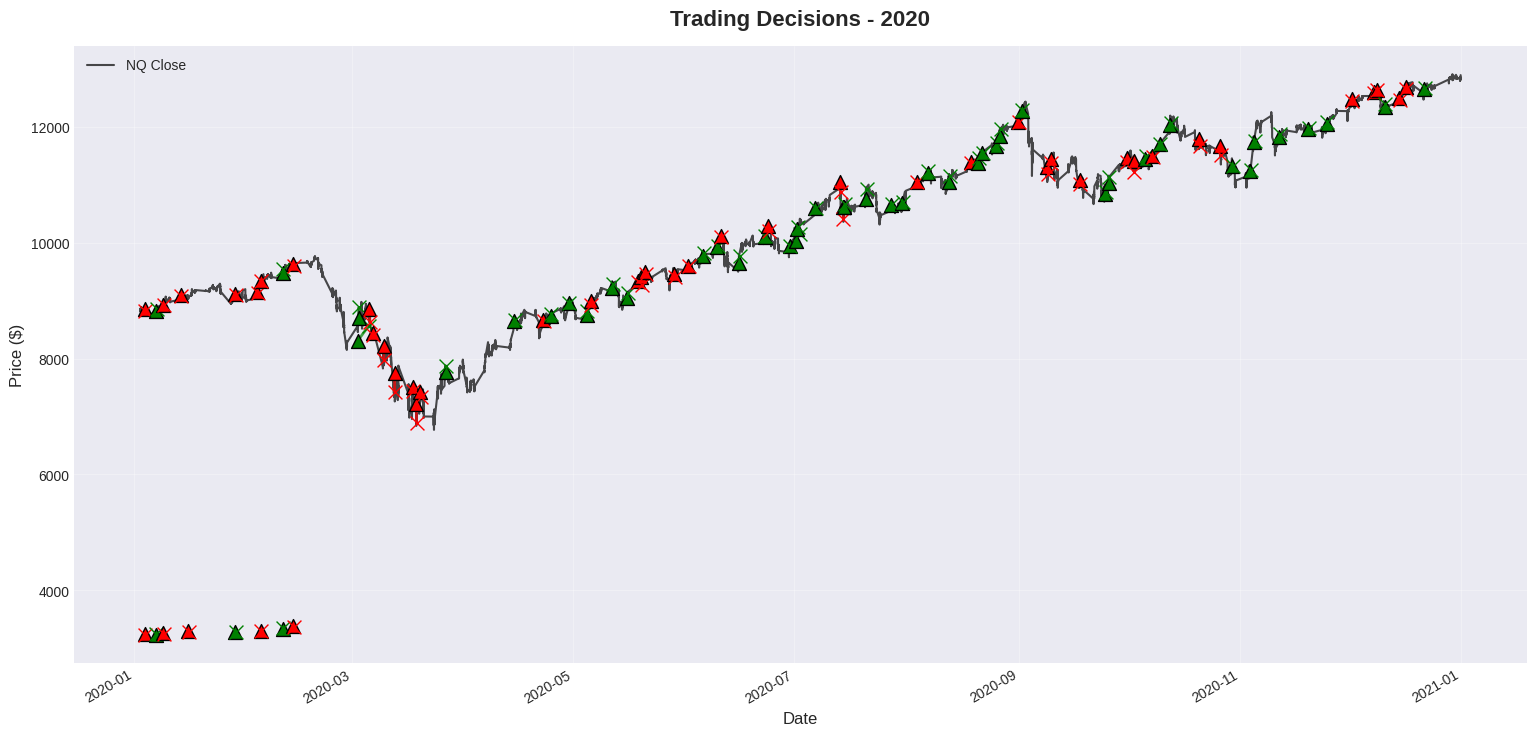


2020 Trades:
  2020-01-03 19:10 NQ long -> $-2,076 (momentum_failure, 54 bars)
  2020-01-03 20:55 ES long -> $-514 (session_close, 47 bars)
  2020-01-06 20:55 ES long -> $498 (session_close, 34 bars)
  2020-01-06 20:55 NQ long -> $6,986 (session_close, 67 bars)
  2020-01-08 20:55 ES long -> $-327 (session_close, 51 bars)
  2020-01-08 20:55 NQ long -> $-312 (session_close, 51 bars)
  2020-01-13 20:55 NQ long -> $-1,456 (session_close, 18 bars)
  2020-01-15 20:10 ES long -> $-552 (momentum_failure, 50 bars)
  2020-01-28 20:55 ES long -> $36 (session_close, 35 bars)
  2020-01-28 20:55 NQ long -> $-2,618 (session_close, 23 bars)
  2020-02-03 20:55 NQ long -> $-1,310 (session_close, 71 bars)
  2020-02-04 20:55 ES long -> $-264 (session_close, 44 bars)
  2020-02-04 20:55 NQ long -> $-410 (session_close, 50 bars)
  2020-02-10 20:55 ES long -> $723 (session_close, 68 bars)
  2020-02-10 20:55 NQ long -> $7,998 (session_close, 64 bars)
  2020-02-13 20:55 ES long -> $-240 (session_close, 38 bars

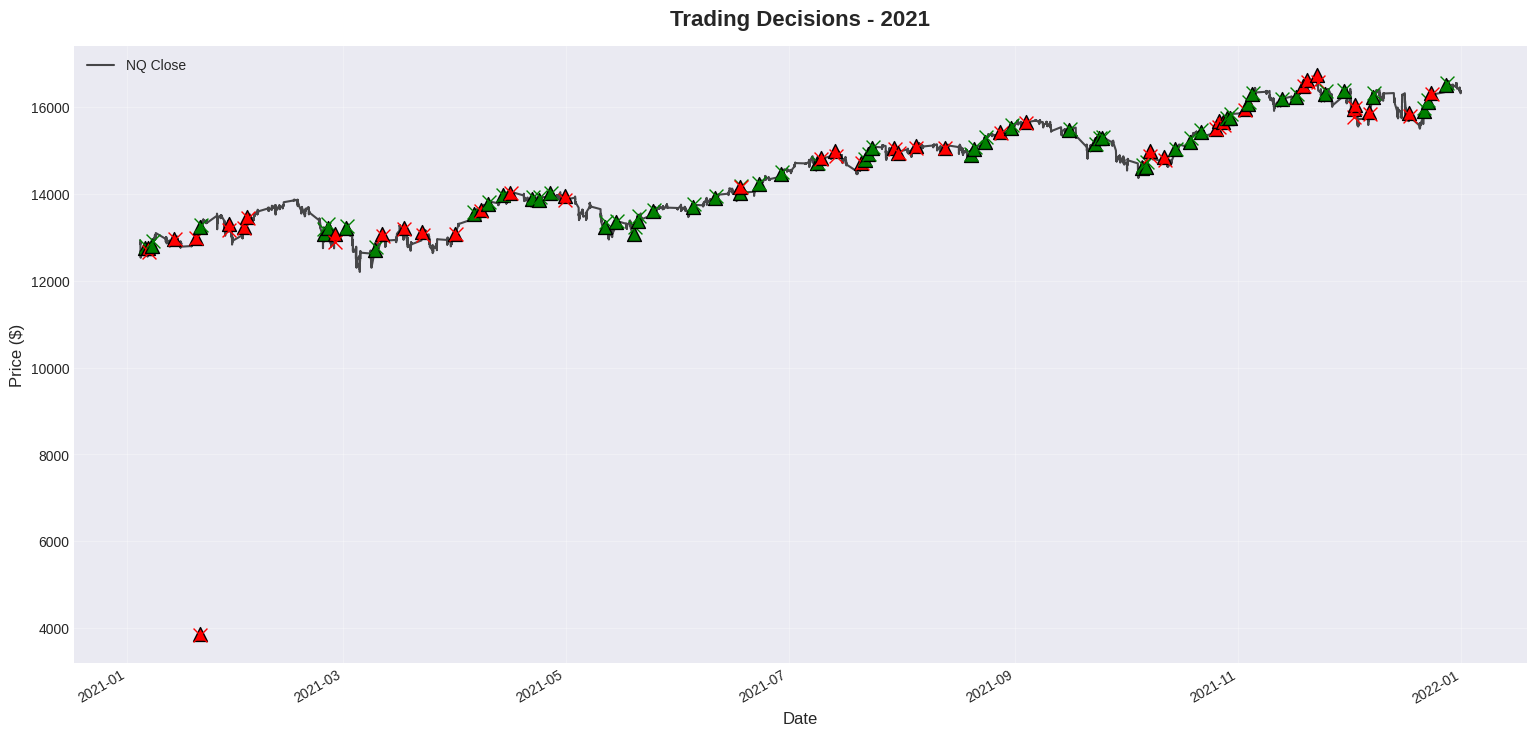


2021 Trades:
  2021-01-05 20:55 NQ long -> $3,452 (session_close, 75 bars)
  2021-01-06 20:25 NQ long -> $-5,556 (momentum_failure, 55 bars)
  2021-01-07 20:55 NQ long -> $4,816 (session_close, 75 bars)
  2021-01-13 20:55 NQ long -> $-585 (session_close, 54 bars)
  2021-01-19 20:55 NQ long -> $-492 (session_close, 13 bars)
  2021-01-20 20:55 ES long -> $-302 (session_close, 15 bars)
  2021-01-20 20:55 NQ long -> $2,196 (session_close, 69 bars)
  2021-01-28 20:55 NQ long -> $-15,135 (session_close, 47 bars)
  2021-02-01 20:55 NQ long -> $-2,709 (session_close, 16 bars)
  2021-02-02 20:55 NQ long -> $-2,322 (session_close, 45 bars)
  2021-02-23 20:55 NQ long -> $7,952 (session_close, 13 bars)
  2021-02-24 20:55 NQ long -> $7,415 (session_close, 38 bars)
  2021-02-26 20:55 NQ long -> $-10,836 (session_close, 45 bars)
  2021-03-01 20:55 NQ long -> $3,692 (session_close, 51 bars)
  2021-03-09 20:55 NQ long -> $1,508 (session_close, 71 bars)
  2021-03-11 20:55 NQ long -> $-4,810 (session_cl

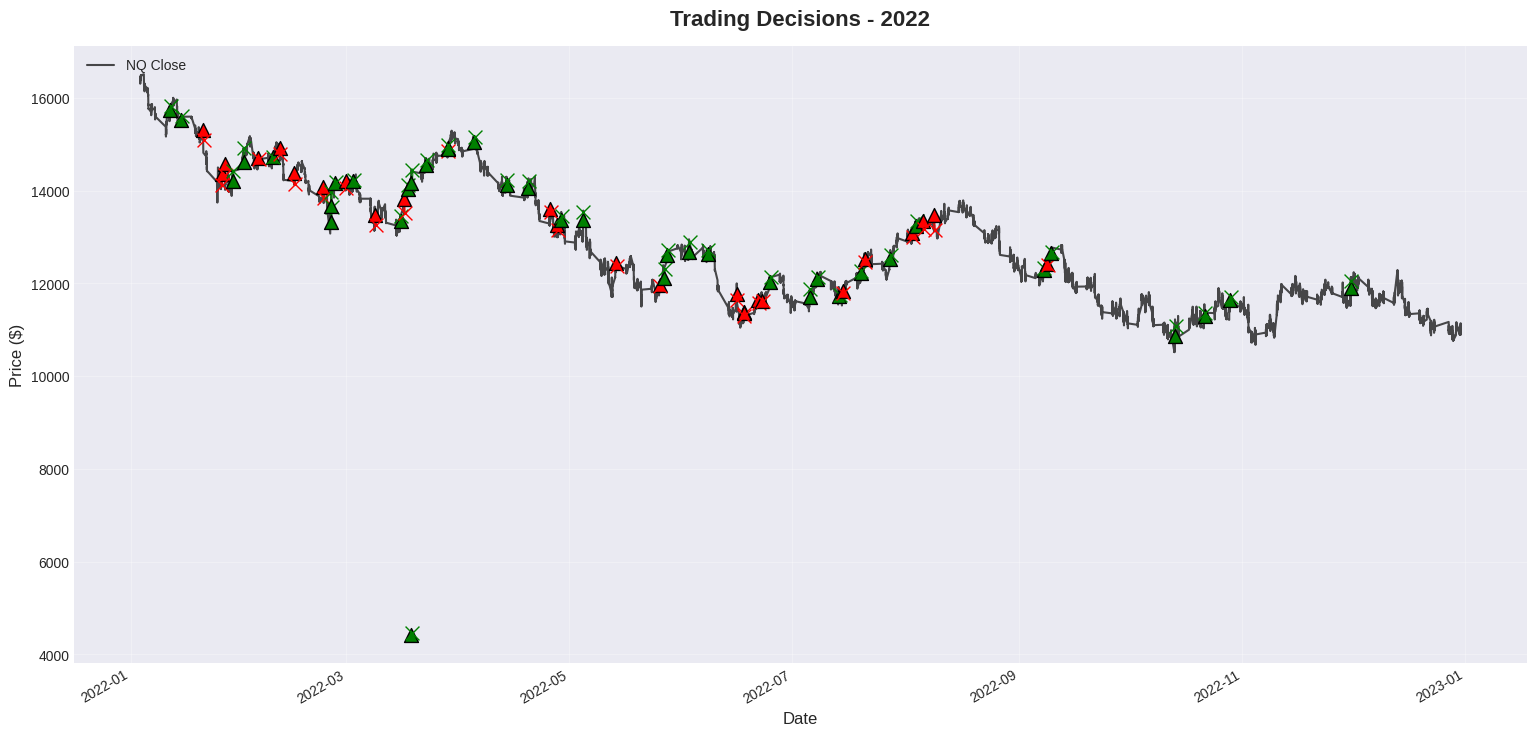


2022 Trades:
  2022-01-11 20:55 NQ long -> $3,276 (session_close, 56 bars)
  2022-01-14 20:55 NQ long -> $3,096 (session_close, 75 bars)
  2022-01-20 19:40 NQ long -> $-11,976 (trailing_stop, 50 bars)
  2022-01-25 20:50 NQ long -> $-14,016 (trailing_stop, 13 bars)
  2022-01-26 19:40 NQ long -> $-13,821 (trailing_stop, 7 bars)
  2022-01-28 20:55 NQ long -> $8,876 (session_close, 53 bars)
  2022-01-31 20:55 NQ long -> $17,619 (session_close, 72 bars)
  2022-02-04 20:55 NQ long -> $-2,168 (session_close, 35 bars)
  2022-02-08 20:55 NQ long -> $390 (session_close, 41 bars)
  2022-02-10 19:05 NQ long -> $-2,502 (momentum_failure, 50 bars)
  2022-02-14 18:55 NQ long -> $-14,781 (trailing_stop, 17 bars)
  2022-02-22 17:30 NQ long -> $-9,794 (trailing_stop, 32 bars)
  2022-02-24 19:10 NQ long -> $6,078 (profit_target, 53 bars)
  2022-02-24 20:55 NQ long -> $11,906 (session_close, 20 bars)
  2022-02-25 20:55 NQ long -> $1,014 (session_close, 48 bars)
  2022-02-28 19:50 NQ long -> $-6,364 (mome

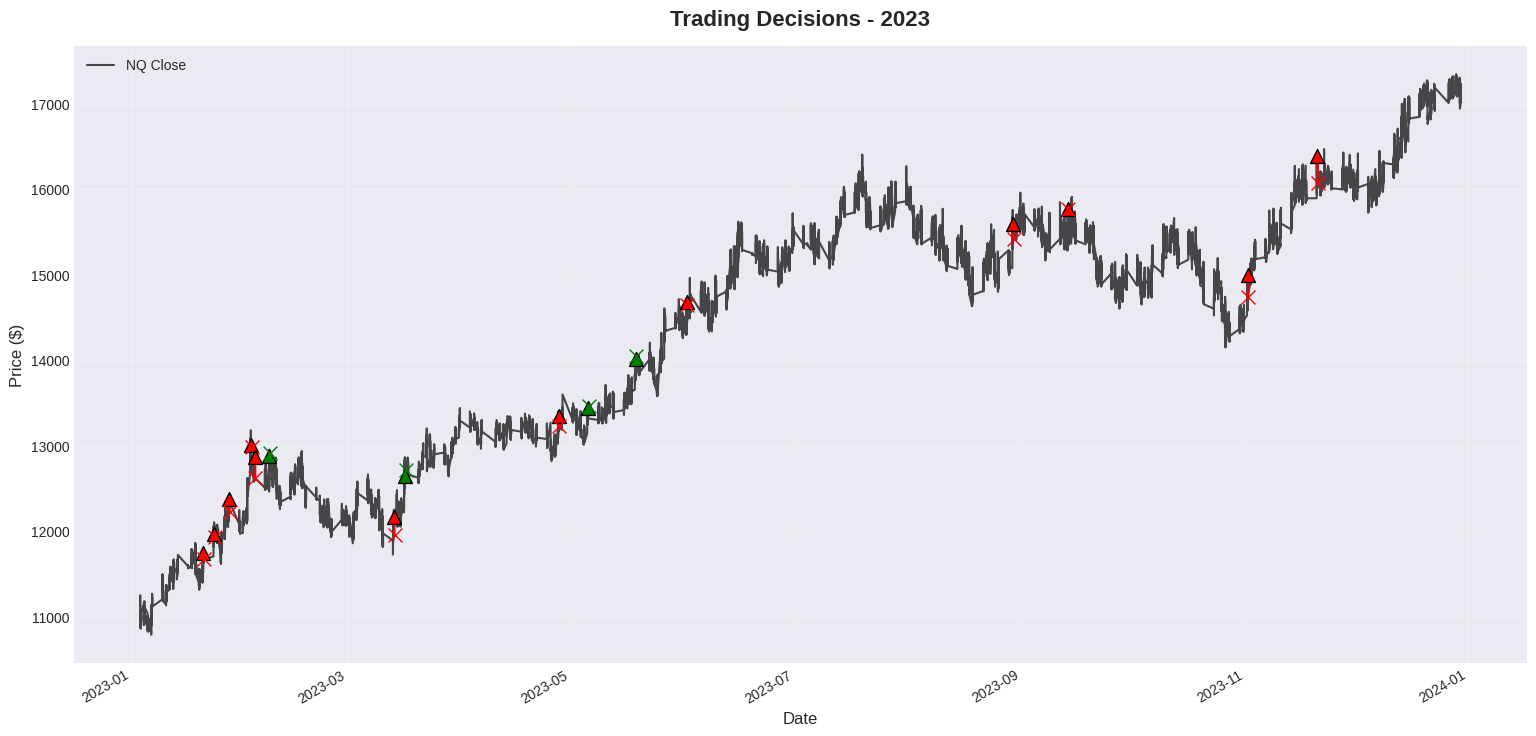


2023 Trades:
  2023-01-20 20:55 NQ long -> $-1,312 (session_close, 17 bars)
  2023-01-23 20:55 NQ long -> $-1,494 (session_close, 29 bars)
  2023-01-27 20:55 NQ long -> $-3,082 (session_close, 28 bars)
  2023-02-02 20:55 NQ long -> $-452 (session_close, 29 bars)
  2023-02-03 20:55 NQ long -> $-4,837 (session_close, 36 bars)
  2023-02-07 20:55 NQ long -> $818 (session_close, 36 bars)
  2023-03-13 19:50 NQ long -> $-4,337 (momentum_failure, 53 bars)
  2023-03-16 19:55 NQ long -> $1,498 (session_close, 60 bars)
  2023-04-27 19:55 NQ long -> $-2,387 (session_close, 26 bars)
  2023-05-05 19:55 NQ long -> $473 (session_close, 28 bars)
  2023-05-18 19:55 NQ long -> $773 (session_close, 50 bars)
  2023-06-01 19:55 NQ long -> $-797 (session_close, 12 bars)
  2023-08-29 19:55 NQ long -> $-3,497 (session_close, 16 bars)
  2023-09-13 19:55 NQ long -> $-117 (session_close, 14 bars)
  2023-11-01 19:55 NQ long -> $-5,157 (session_close, 16 bars)
  2023-11-20 18:45 NQ long -> $-6,357 (momentum_failur

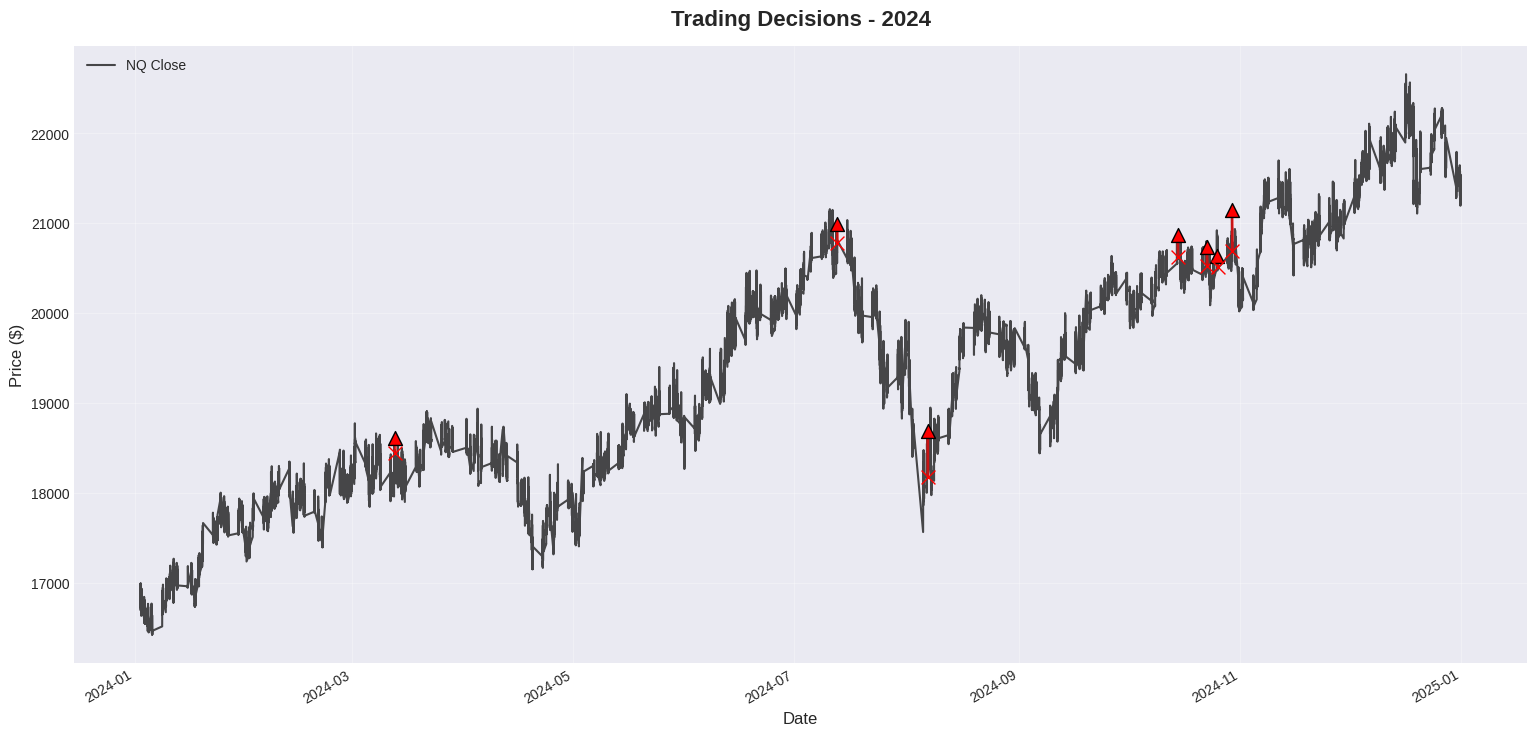


2024 Trades:
  2024-03-12 18:45 NQ long -> $-3,342 (momentum_failure, 51 bars)
  2024-07-12 19:55 NQ long -> $-4,187 (session_close, 25 bars)
  2024-08-06 19:55 NQ long -> $-10,247 (session_close, 17 bars)
  2024-10-14 18:15 NQ long -> $-4,922 (momentum_failure, 50 bars)
  2024-10-22 19:00 NQ long -> $-4,207 (momentum_failure, 58 bars)
  2024-10-25 18:00 NQ long -> $-2,307 (momentum_failure, 50 bars)
  2024-10-29 19:55 NQ long -> $-9,072 (session_close, 18 bars)


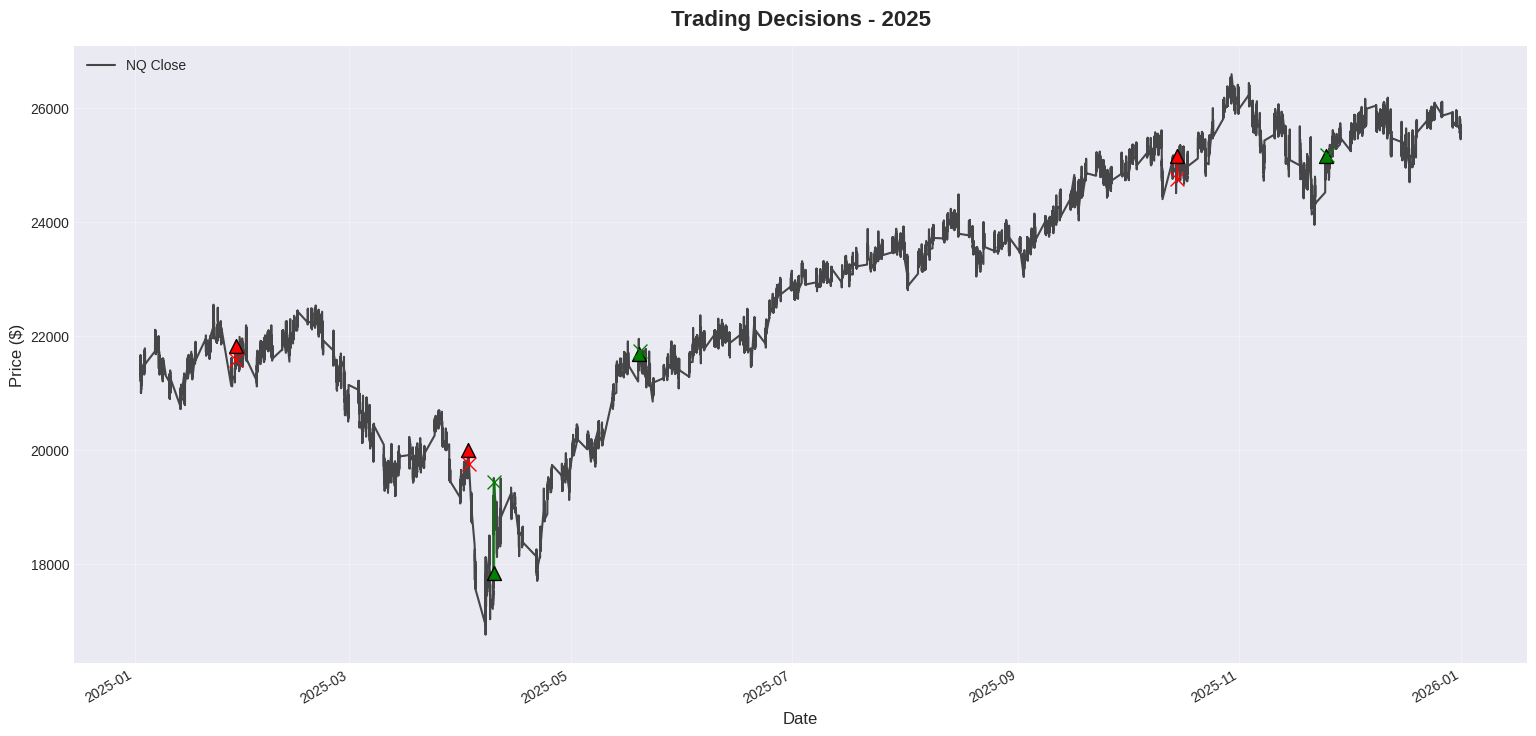


2025 Trades:
  2025-01-28 20:55 NQ long -> $-5,172 (session_close, 15 bars)
  2025-04-02 19:55 NQ long -> $-5,182 (session_close, 37 bars)
  2025-04-09 19:55 NQ long -> $32,058 (session_close, 35 bars)
  2025-05-19 19:55 NQ long -> $1,308 (session_close, 51 bars)
  2025-10-14 19:55 NQ long -> $-8,237 (session_close, 37 bars)
  2025-11-24 20:55 NQ long -> $398 (session_close, 39 bars)


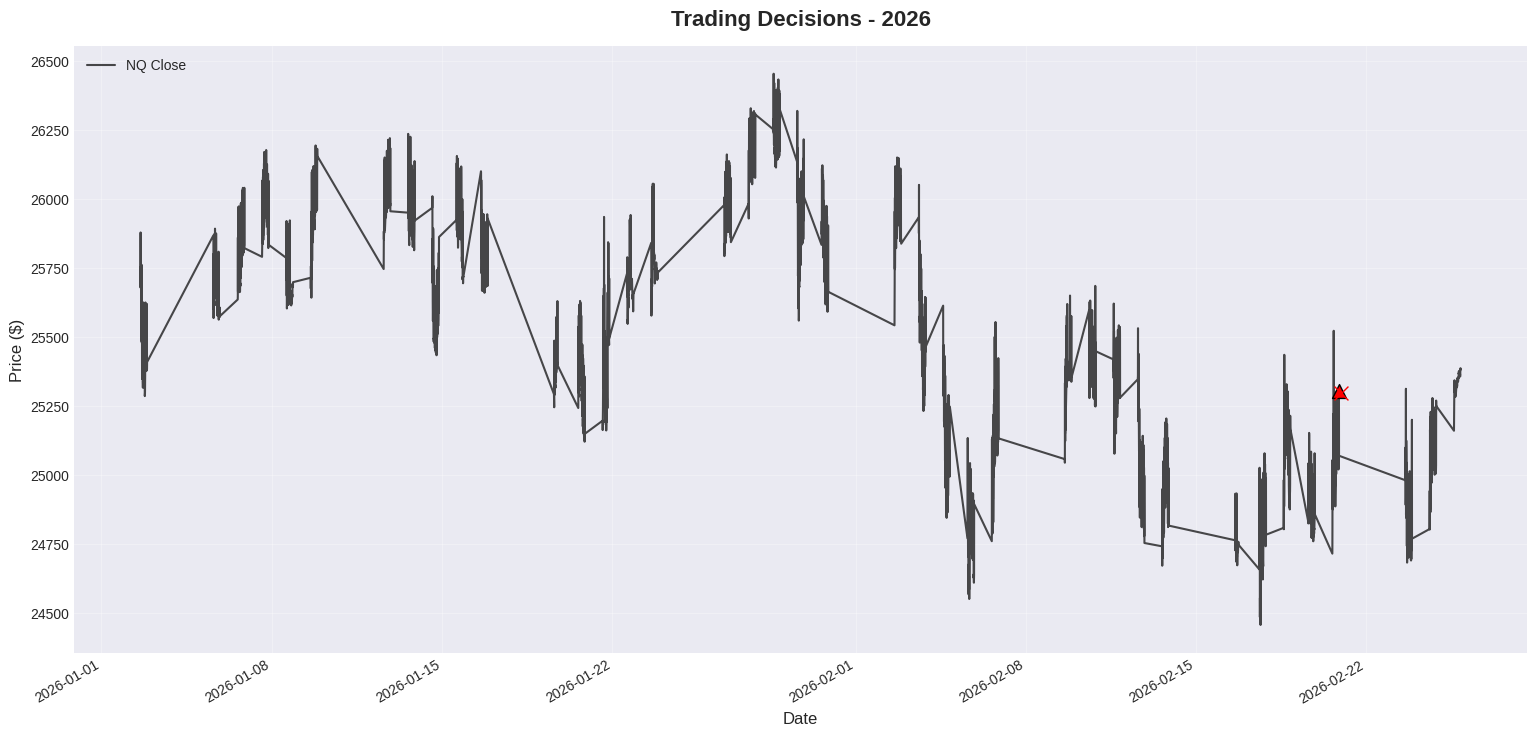


2026 Trades:
  2026-02-20 20:55 NQ long -> $-167 (session_close, 26 bars)


In [17]:
# Plot trading decisions per year
if len(trades_df) > 0:
    trades_df['year'] = trades_df['timestamp'].dt.year
    years = sorted(trades_df['year'].unique())
    
    for year in years:
        year_trades = trades_df[trades_df['year'] == year]
        
        fig, ax = plt.subplots(figsize=(16, 8))
        
        # Plot NQ price for the year (if available)
        year_start = f"{year}-01-01"
        year_end = f"{year}-12-31"
        year_data = nq_data.loc[year_start:year_end]
        if len(year_data) > 0:
            ax.plot(year_data.index, year_data['Close'], linewidth=1.5, color='black', alpha=0.7, label='NQ Close')
        
        # Plot trades
        for _, trade in year_trades.iterrows():
            entry_time = trade['timestamp']
            exit_time = entry_time + pd.Timedelta(minutes=trade['holding_bars'] * 5)
            
            color = 'green' if trade['pnl_net'] > 0 else 'red'
            marker = '^' if trade['side'] == 'long' else 'v'
            
            # Entry point
            ax.scatter(entry_time, trade['entry_price'], marker=marker, s=100, 
                      color=color, edgecolor='black', linewidth=1, zorder=5,
                      label=f"{trade['side'].capitalize()} Entry" if _ == 0 else "")
            
            # Exit point
            ax.scatter(exit_time, trade['exit_price'], marker='x', s=100, 
                      color=color, edgecolor='black', linewidth=1, zorder=5,
                      label=f"Exit (${trade['pnl_net']:,.0f})" if _ == 0 else "")
            
            # Line connecting entry to exit
            ax.plot([entry_time, exit_time], [trade['entry_price'], trade['exit_price']], 
                   color=color, linewidth=2, alpha=0.7)
        
        ax.set_title(f'Trading Decisions - {year}', fontsize=16, fontweight='bold', pad=15)
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Price ($)', fontsize=12)
        ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
        ax.grid(True, alpha=0.3)
        fig.autofmt_xdate()
        plt.tight_layout(pad=3.0)
        plt.savefig(f'results/trades_{year}.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\n{year} Trades:")
        for _, trade in year_trades.iterrows():
            print(f"  {trade['timestamp'].strftime('%Y-%m-%d %H:%M')} {trade['symbol']} {trade['side']} -> "
                  f"${trade['pnl_net']:,.0f} ({trade['exit_reason']}, {trade['holding_bars']} bars)")


## 10. Save Results

In [18]:
# Save all results
portfolio['ES_momentum'].to_csv('results/es_momentum_data.csv')
portfolio['NQ_momentum'].to_csv('results/nq_momentum_data.csv')
portfolio['NQ_long_only'].to_csv('results/nq_long_only_data.csv')
equity_curve.to_csv('results/equity_curve.csv')
trades_df.to_csv('results/trades.csv')

# Save metrics
metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ['Value']
metrics_df.to_csv('results/performance_metrics.csv')

print("✓ All results saved to results/ directory")
print("\nFiles created:")
print("  - es_momentum_data.csv")
print("  - nq_momentum_data.csv")
print("  - nq_long_only_data.csv")
print("  - equity_curve.csv")
print("  - trades.csv")
print("  - performance_metrics.csv")
print("  - Various PNG visualizations")

✓ All results saved to results/ directory

Files created:
  - es_momentum_data.csv
  - nq_momentum_data.csv
  - nq_long_only_data.csv
  - equity_curve.csv
  - trades.csv
  - performance_metrics.csv
  - Various PNG visualizations


In [19]:
# Walk-Forward Analysis for Overfitting Check
print("=" * 60)
print("WALK-FORWARD ANALYSIS")
print("=" * 60)

# Split data into training and testing periods
train_end_date = pd.Timestamp('2018-12-31', tz='UTC')
test_start_date = pd.Timestamp('2019-01-01', tz='UTC')

print(f"Training period: {nq_data.index.min()} to {train_end_date}")
print(f"Testing period: {test_start_date} to {nq_data.index.max()}")

# Run backtest on training data to optimize parameters
# (In practice, you'd optimize parameters here)

# Then run on test data with fixed parameters
test_data = nq_data[nq_data.index >= test_start_date].copy()

# Re-run the full pipeline on test data
print("\nRunning strategy on out-of-sample test data...")

# Generate signals
signal_gen = SignalGenerator(config)
test_signals = signal_gen.generate_signals(test_data)

# Calculate position sizes
sizer = PositionSizer(config)
test_portfolio = sizer.calculate_portfolio_positions(test_signals, test_signals)  # Assuming same for both, but adjust

# Run backtest
backtester = Backtester(config)
test_equity_curve = backtester.run_backtest(test_portfolio)

# Evaluate performance
evaluator = PerformanceEvaluator(config)
test_metrics = evaluator.evaluate_strategy(test_equity_curve, backtester.get_trades_dataframe())

print("\nOut-of-Sample Performance:")
print(f"Total Return: {test_metrics['total_return']:.2%}")
print(f"Sharpe Ratio: {test_metrics['sharpe_ratio']:.2f}")
print(f"Max Drawdown: {test_metrics['max_drawdown']:.2%}")
print(f"Win Rate: {test_metrics['win_rate']:.1%}")
print(f"Profit Factor: {test_metrics['profit_factor']:.2f}")

# Compare to in-sample
print("\nComparison:")
print(f"In-Sample Sharpe: {metrics['sharpe_ratio']:.2f}")
print(f"Out-of-Sample Sharpe: {test_metrics['sharpe_ratio']:.2f}")
print(f"Sharpe Degradation: {metrics['sharpe_ratio'] - test_metrics['sharpe_ratio']:.2f}")

if test_metrics['sharpe_ratio'] < 0.5:
    print(" WARNING: Out-of-sample performance is poor - likely overfitting!")
else:
    print("✓ Out-of-sample performance looks reasonable.")

WALK-FORWARD ANALYSIS
Training period: 2011-01-03 14:25:00+00:00 to 2018-12-31 00:00:00+00:00
Testing period: 2019-01-01 00:00:00+00:00 to 2026-02-25 21:00:00+00:00

Running strategy on out-of-sample test data...
SIGNAL GENERATION
Processing 145172 bars...

Signal Statistics:
  Entry signals: 329
    Long: 329
    Short: 0
  Exit signals: 329
  Exit reasons:
    session_close: 256
    momentum_failure: 51
    trailing_stop: 17
    profit_target: 3
    new_session: 2
  Avg signal strength: 56.1
POSITION SIZING
Portfolio value: $2,500,000
Target volatility: 10.0%
Leverage bounds: 1.0x - 8.0x

Calculating volatility...
  ES avg vol: 59.3%
  NQ avg vol: 59.3%

Calculating position sizes...

Position Statistics:
  ES momentum:
    Active bars:    14 of 145,172 (0.0%)
    Avg size (when active): 1.0 contracts
    Max size:        1 contracts
    Avg leverage (when active): 0.16x
    Max leverage:    0.18x
  NQ momentum:
    Active bars:    13,684 of 145,172 (9.4%)
    Avg size (when active):

## 8. Separate Period Backtests

Analyze performance in different market regimes by running independent backtests on separate time periods.

In [20]:
# Function to run backtest on specific date range
def run_period_backtest(start_date, end_date, period_name):
    print(f"\n{'='*60}")
    print(f"BACKTESTING {period_name.upper()}: {start_date.date()} to {end_date.date()}")
    print(f"{'='*60}")
    
    # Filter data to the specific period
    period_es_data = es_data[(es_data.index >= start_date) & (es_data.index <= end_date)].copy()
    period_nq_data = nq_data[(nq_data.index >= start_date) & (nq_data.index <= end_date)].copy()
    
    if len(period_es_data) == 0 or len(period_nq_data) == 0:
        print(f"No data available for {period_name} period")
        return None, None
    
    # Re-run position sizing for this period
    period_sizer = PositionSizer(config)
    period_portfolio = period_sizer.calculate_portfolio_positions(period_es_data, period_nq_data)
    
    # Run backtest
    period_backtester = Backtester(config)
    period_equity_curve = period_backtester.run_backtest(period_portfolio)
    period_trades_df = period_backtester.get_trades_dataframe()
    
    # Evaluate performance
    period_evaluator = PerformanceEvaluator(config)
    period_metrics = period_evaluator.evaluate_strategy(period_equity_curve, period_trades_df)
    
    print(f"\n{period_name.upper()} Results:")
    print(f"  Trades: {len(period_trades_df)}")
    print(f"  Total Return: {period_metrics['total_return']:.2%}")
    print(f"  Sharpe Ratio: {period_metrics['sharpe_ratio']:.2f}")
    print(f"  Max Drawdown: {period_metrics['max_drawdown']:.2%}")
    
    return period_equity_curve, period_trades_df

# Define periods
early_start = pd.Timestamp('2011-01-01', tz='UTC')
early_end = pd.Timestamp('2023-12-31', tz='UTC')
late_start = pd.Timestamp('2024-01-01', tz='UTC')
late_end = pd.Timestamp('2026-12-31', tz='UTC')

# Run separate backtests
print("Running separate period backtests...")

early_equity, early_trades = run_period_backtest(early_start, early_end, "Early Period (2011-2023)")
late_equity, late_trades = run_period_backtest(late_start, late_end, "Late Period (2024-2026)")


Running separate period backtests...

BACKTESTING EARLY PERIOD (2011-2023): 2011-01-01 to 2023-12-31
POSITION SIZING
Portfolio value: $2,500,000
Target volatility: 10.0%
Leverage bounds: 1.0x - 8.0x

Calculating volatility...
  ES avg vol: 37.2%
  NQ avg vol: 28.6%

Calculating position sizes...

Position Statistics:
  ES momentum:
    Active bars:    2,915 of 262,918 (1.1%)
    Avg size (when active): 1.2 contracts
    Max size:        4 contracts
    Avg leverage (when active): 0.07x
    Max leverage:    0.21x
  NQ momentum:
    Active bars:    33,698 of 262,916 (12.8%)
    Avg size (when active): 17.8 contracts
    Max size:        50 contracts
    Avg leverage (when active): 0.68x
    Max leverage:    2.81x
  NQ long-only:
    Avg size (when active): 0.0 contracts
    Max size:        0 contracts
    Avg leverage (when active): 0.00x
    Max leverage:    0.00x
BACKTESTING
Initial capital: $2,500,000
Transaction costs:
  Slippage: 0.5 ticks per side
  Commission: $2.00 per contract


### Period Comparison

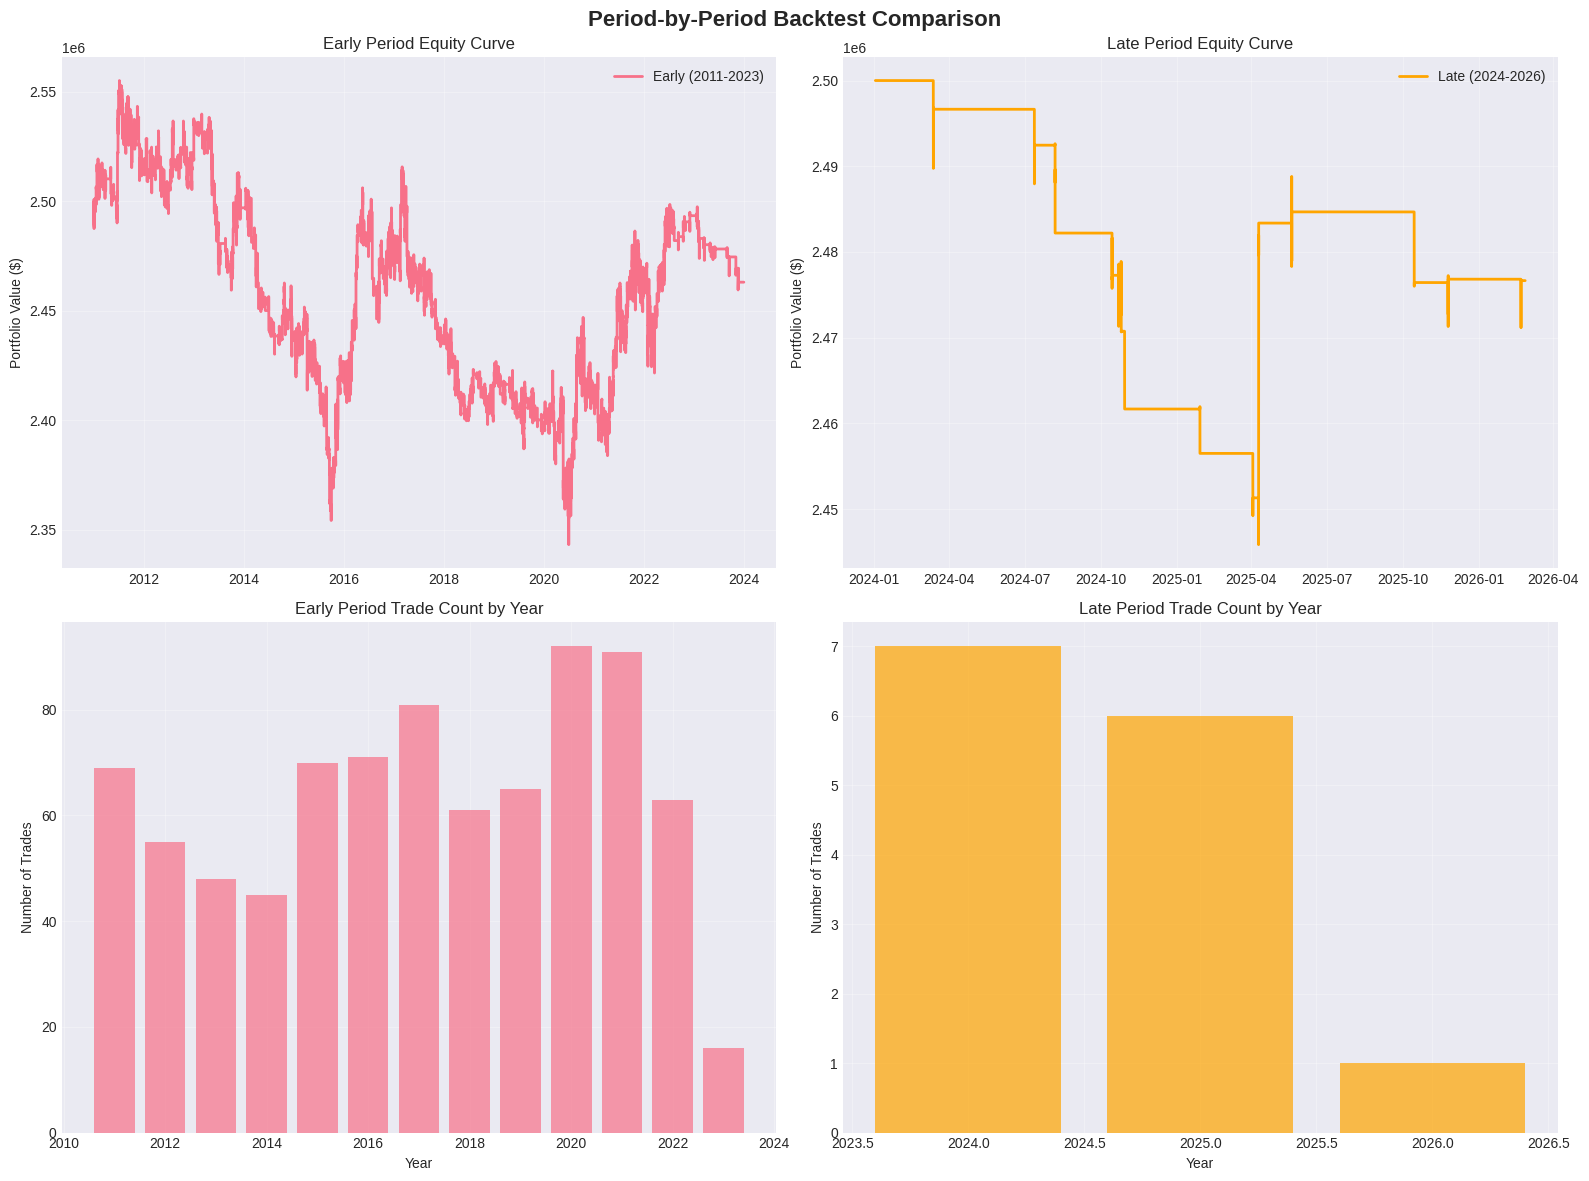


Period Comparison Summary:
Early Period (2011-2023): 827 trades
Late Period (2024-2026): 14 trades
Early Win Rate: 50.4%
Late Win Rate: 21.4%


In [21]:
# Compare the two periods
if early_equity is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Period-by-Period Backtest Comparison', fontsize=16, fontweight='bold')
    
    # Equity curves
    axes[0,0].plot(early_equity.index, early_equity['portfolio_value'], label='Early (2011-2023)', linewidth=2)
    axes[0,0].set_title('Early Period Equity Curve')
    axes[0,0].set_ylabel('Portfolio Value ($)')
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].legend()
    
    if late_equity is not None:
        axes[0,1].plot(late_equity.index, late_equity['portfolio_value'], label='Late (2024-2026)', color='orange', linewidth=2)
        axes[0,1].set_title('Late Period Equity Curve')
        axes[0,1].set_ylabel('Portfolio Value ($)')
        axes[0,1].grid(True, alpha=0.3)
        axes[0,1].legend()
    else:
        axes[0,1].text(0.5, 0.5, 'No Trades in Late Period\n(2024-2026)', 
                      ha='center', va='center', transform=axes[0,1].transAxes, fontsize=14)
        axes[0,1].set_title('Late Period: NO TRADES')
    
    # Trade counts by year
    early_years = early_trades['timestamp'].dt.year.value_counts().sort_index()
    
    axes[1,0].bar(early_years.index, early_years.values, alpha=0.7, label='Early Period')
    axes[1,0].set_title('Early Period Trade Count by Year')
    axes[1,0].set_xlabel('Year')
    axes[1,0].set_ylabel('Number of Trades')
    axes[1,0].grid(True, alpha=0.3)
    
    if late_trades is not None and len(late_trades) > 0:
        late_years = late_trades['timestamp'].dt.year.value_counts().sort_index()
        axes[1,1].bar(late_years.index, late_years.values, alpha=0.7, color='orange', label='Late Period')
        axes[1,1].set_title('Late Period Trade Count by Year')
        axes[1,1].set_xlabel('Year')
        axes[1,1].set_ylabel('Number of Trades')
        axes[1,1].grid(True, alpha=0.3)
    else:
        axes[1,1].text(0.5, 0.5, 'No Trades in Late Period\n(2024-2026)', 
                      ha='center', va='center', transform=axes[1,1].transAxes, fontsize=14)
        axes[1,1].set_title('Late Period: NO TRADES')
    
    plt.tight_layout()
    plt.savefig('results/period_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nPeriod Comparison Summary:")
    print(f"Early Period (2011-2023): {len(early_trades)} trades")
    print(f"Late Period (2024-2026): {0 if late_trades is None else len(late_trades)} trades")
    
    if len(early_trades) > 0:
        early_win_rate = (early_trades['pnl_net'] > 0).mean() * 100
        print(f"Early Win Rate: {early_win_rate:.1f}%")
    
    if late_trades is not None and len(late_trades) > 0:
        late_win_rate = (late_trades['pnl_net'] > 0).mean() * 100
        print(f"Late Win Rate: {late_win_rate:.1f}%")
    else:
        print("Late Period: No trades to analyze")

else:
    print("Early period backtest failed - no data available")


In [22]:
# Diagnostic: Why no trades after May 2023?
print("="*80)
print("DIAGNOSTIC: WHY NO TRADES AFTER MAY 2023?")
print("="*80)

# Check signals after May 2023
cutoff_date = pd.Timestamp('2023-05-01', tz='UTC')
late_2023_signals = es_data[es_data.index >= cutoff_date]
late_2023_nq_signals = nq_data[nq_data.index >= cutoff_date]

print(f"Data after May 2023:")
print(f"  ES bars: {len(late_2023_signals)}")
print(f"  NQ bars: {len(late_2023_nq_signals)}")

# Check for entry signals
es_entries_late = late_2023_signals[late_2023_signals['entry_signal']]
nq_entries_late = late_2023_nq_signals[late_2023_nq_signals['entry_signal']]

print(f"\nEntry signals after May 2023:")
print(f"  ES entries: {len(es_entries_late)}")
print(f"  NQ entries: {len(nq_entries_late)}")

if len(es_entries_late) > 0:
    print(f"  ES entry dates: {es_entries_late.index[:5].tolist()}")
if len(nq_entries_late) > 0:
    print(f"  NQ entry dates: {nq_entries_late.index[:5].tolist()}")

# Check position sizes
if 'position_size' in portfolio['ES_momentum'].columns:
    late_positions_es = portfolio['ES_momentum'][portfolio['ES_momentum'].index >= cutoff_date]
    late_positions_nq = portfolio['NQ_momentum'][portfolio['NQ_momentum'].index >= cutoff_date]
    
    es_nonzero = (late_positions_es['position_size'] != 0).sum()
    nq_nonzero = (late_positions_nq['position_size'] != 0).sum()
    
    print(f"\nPosition sizes after May 2023:")
    print(f"  ES non-zero positions: {es_nonzero}/{len(late_positions_es)}")
    print(f"  NQ non-zero positions: {nq_nonzero}/{len(late_positions_nq)}")

# Check market volatility around that time
print(f"\nMarket volatility check (May-Dec 2023):")
may_dec_data = nq_data[(nq_data.index >= '2023-05-01') & (nq_data.index <= '2023-12-31')]
if len(may_dec_data) > 0:
    daily_vol = may_dec_data['Close'].pct_change().rolling(78).std() * np.sqrt(252)  # 78 5-min bars = ~1 day
    avg_vol = daily_vol.mean()
    print(f"  Average daily volatility (May-Dec 2023): {avg_vol:.1%}")
    
    # Check noise area boundaries
    valid_boundaries = may_dec_data['upper_boundary'].notna().sum()
    total_bars = len(may_dec_data)
    print(f"  Valid noise area boundaries: {valid_boundaries}/{total_bars} ({100*valid_boundaries/total_bars:.1f}%)")

# Check if trend filter was active
print(f"\nTrend filter status:")
print(f"  trend_filter_enabled: {config['strategy'].get('trend_filter_enabled', 'Not set')}")

# Check actual trades in that period
actual_trades_late = trades_df[trades_df['timestamp'] >= cutoff_date]
print(f"\nActual trades after May 2023: {len(actual_trades_late)}")
if len(actual_trades_late) > 0:
    print("Trades found:")
    for _, trade in actual_trades_late.iterrows():
        print(f"  {trade['timestamp']} {trade['symbol']} {trade['side']} -> ${trade['pnl_net']:,.0f}")

print("="*80)

DIAGNOSTIC: WHY NO TRADES AFTER MAY 2023?
Data after May 2023:
  ES bars: 57272
  NQ bars: 57272

Entry signals after May 2023:
  ES entries: 24
  NQ entries: 36
  ES entry dates: [Timestamp('2023-06-15 18:25:00+0000', tz='UTC'), Timestamp('2023-10-23 17:00:00+0000', tz='UTC'), Timestamp('2023-11-02 13:35:00+0000', tz='UTC'), Timestamp('2023-12-13 19:45:00+0000', tz='UTC'), Timestamp('2024-02-22 17:55:00+0000', tz='UTC')]
  NQ entry dates: [Timestamp('2023-05-05 17:35:00+0000', tz='UTC'), Timestamp('2023-05-18 15:45:00+0000', tz='UTC'), Timestamp('2023-06-01 18:55:00+0000', tz='UTC'), Timestamp('2023-06-15 18:40:00+0000', tz='UTC'), Timestamp('2023-08-10 13:50:00+0000', tz='UTC')]

Position sizes after May 2023:
  ES non-zero positions: 0/57272
  NQ non-zero positions: 869/57272

Market volatility check (May-Dec 2023):
  Average daily volatility (May-Dec 2023): 12.4%
  Valid noise area boundaries: 13667/13667 (100.0%)

Trend filter status:
  trend_filter_enabled: Not set

Actual trades